<a href="https://colab.research.google.com/github/aidapassela/Test/blob/main/Data_Analysis%2C_Revenue_Loss_Analysis_(FINAL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Cancellation Analysis

This project analyzes hotel reservation data to identify patterns in booking cancellations and no-shows. The objective is to explore factors influencing reservation outcomes, quantify revenue loss caused by cancellations, and develop a predictive model to estimate cancellation probability.

# Data Analysis

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Load Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
validation= pd.read_csv('/content/drive/MyDrive/GCW/Data/Raw/Hotel-A-validation.csv')
train= pd.read_csv('/content/drive/MyDrive/GCW/Data/Raw/Hotel-A-train.csv')
test= pd.read_csv('/content/drive/MyDrive/GCW/Data/Raw/Hotel-A-test.csv')

Basic Dataset Overview

In [ ]:
# Check dataset dimensions (rows, columns)
validation.shape

(2749, 24)

In [ ]:
train.shape

(27499, 24)

In [ ]:
test.shape

(4318, 23)

Preview the Data

In [ ]:
# Display first few rows of the dataset
validation.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,45716350,M,56,caucasian,Grad,<25K,West,Resort,8/31/2016,9/2/2016,...,HB,No,No,No Deposit,Agent,No,No-Show,Yes,15,192
1,88857401,M,60,Latino,College,25K --50K,West,Resort,8/31/2016,9/4/2016,...,FB,Yes,No,No Deposit,Online,Yes,Canceled,No,0,187
2,16074440,F,58,Asian American,College,<25K,North,Airport Hotels,9/1/2016,9/2/2016,...,FB,No,No,No Deposit,Direct,No,Canceled,Yes,10,227
3,10992124,F,23,Latino,College,25K --50K,East,Airport Hotels,8/31/2016,9/2/2016,...,FB,Yes,No,Refundable,Direct,No,Check-In,Yes,25,189
4,15934351,F,47,Asian American,College,25K --50K,South,City Hotel,8/31/2016,9/1/2016,...,HB,Yes,No,No Deposit,Online,Yes,Check-In,Yes,10,218


In [ ]:
train.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,7/2/2015,7/6/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,7/2/2015,7/3/2015,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,7/3/2015,7/4/2015,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242


In [ ]:
test.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Babies,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Use_Promotion,Discount_Rate,Room_Rate
0,62931593,F,52,Latino,Grad,25K --50K,South,City Hotel,11/18/2016,11/19/2016,...,0,HB,No,No,No Deposit,Direct,Yes,Yes,10,153
1,70586099,F,47,Latino,Grad,25K --50K,East,Airport Hotels,11/18/2016,11/19/2016,...,0,FB,No,No,No Deposit,Online,No,No,0,210
2,4230648,F,28,Asian American,Grad,<25K,East,City Hotel,4/28/2017,5/1/2017,...,0,BB,No,No,No Deposit,Agent,No,Yes,5,117
3,25192322,F,65,caucasian,High-School,25K --50K,South,Airport Hotels,11/18/2016,11/20/2016,...,2,FB,No,No,No Deposit,Online,Yes,Yes,10,107
4,80931528,M,45,African American,College,25K --50K,South,City Hotel,11/18/2016,11/20/2016,...,0,BB,No,No,Refundable,Agent,No,No,0,119


Data Types

In [ ]:
# Display column names, data types, and non-null counts
validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2749 entries, 0 to 2748
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          2749 non-null   int64 
 1   Gender                  2749 non-null   object
 2   Age                     2749 non-null   int64 
 3   Ethnicity               2749 non-null   object
 4   Educational_Level       2749 non-null   object
 5   Income                  2749 non-null   object
 6   Country_region          2749 non-null   object
 7   Hotel_Type              2749 non-null   object
 8   Expected_checkin        2749 non-null   object
 9   Expected_checkout       2749 non-null   object
 10  Booking_date            2749 non-null   object
 11  Adults                  2749 non-null   int64 
 12  Children                2749 non-null   int64 
 13  Babies                  2749 non-null   int64 
 14  Meal_Type               2749 non-null   object
 15  Vist

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          27499 non-null  int64 
 1   Gender                  27499 non-null  object
 2   Age                     27499 non-null  int64 
 3   Ethnicity               27499 non-null  object
 4   Educational_Level       27499 non-null  object
 5   Income                  27499 non-null  object
 6   Country_region          27499 non-null  object
 7   Hotel_Type              27499 non-null  object
 8   Expected_checkin        27499 non-null  object
 9   Expected_checkout       27499 non-null  object
 10  Booking_date            27499 non-null  object
 11  Adults                  27499 non-null  int64 
 12  Children                27499 non-null  int64 
 13  Babies                  27499 non-null  int64 
 14  Meal_Type               27499 non-null  object
 15  Vi

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4318 entries, 0 to 4317
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          4318 non-null   int64 
 1   Gender                  4318 non-null   object
 2   Age                     4318 non-null   int64 
 3   Ethnicity               4318 non-null   object
 4   Educational_Level       4318 non-null   object
 5   Income                  4318 non-null   object
 6   Country_region          4318 non-null   object
 7   Hotel_Type              4318 non-null   object
 8   Expected_checkin        4318 non-null   object
 9   Expected_checkout       4318 non-null   object
 10  Booking_date            4318 non-null   object
 11  Adults                  4318 non-null   int64 
 12  Children                4318 non-null   int64 
 13  Babies                  4318 non-null   int64 
 14  Meal_Type               4318 non-null   object
 15  Vist

Summary Statistics

Numerical Variables Summary

In [ ]:
validation.describe().T

,count,mean,std,min,25%,50%,75%,max
Reservation-id,2749.0,4.991827e+07,2.888011e+07,143.0,24843132.0,49328761.0,74712969.0,99988487.0
Age,2749.0,4.419680e+01,1.521221e+01,18.0,31.0,44.0,57.0,70.0
Adults,2749.0,2.336850e+00,1.185808e+00,1.0,1.0,2.0,3.0,5.0
Children,2749.0,1.740633e+00,7.249131e-01,1.0,1.0,2.0,2.0,3.0
Babies,2749.0,3.339396e-01,5.669973e-01,0.0,0.0,0.0,1.0,2.0
Discount_Rate,2749.0,1.248454e+01,1.116618e+01,0.0,5.0,10.0,20.0,40.0
Room_Rate,2749.0,1.737425e+02,4.388018e+01,100.0,136.0,173.0,212.0,250.0


In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Reservation-id,27499.0,5.016461e+07,2.886911e+07,3154.0,25239432.0,50149955.0,75182883.0,99999005.0
Age,27499.0,4.397745e+01,1.530315e+01,18.0,31.0,44.0,57.0,70.0
Adults,27499.0,2.333576e+00,1.176526e+00,1.0,2.0,2.0,3.0,5.0
Children,27499.0,1.743882e+00,7.219721e-01,1.0,1.0,2.0,2.0,3.0
Babies,27499.0,3.515401e-01,5.733259e-01,0.0,0.0,0.0,1.0,2.0
Discount_Rate,27499.0,1.249518e+01,1.120604e+01,0.0,5.0,10.0,20.0,40.0
Room_Rate,27499.0,1.751365e+02,4.387709e+01,100.0,137.0,175.0,214.0,250.0


In [ ]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
Reservation-id,4318.0,5.042908e+07,2.879425e+07,68318.0,25476853.0,51123488.0,75158645.0,99983667.0
Age,4318.0,4.378833e+01,1.525708e+01,18.0,31.0,44.0,57.0,70.0
Adults,4318.0,2.369847e+00,1.191075e+00,1.0,2.0,2.0,3.0,5.0
Children,4318.0,1.730199e+00,7.214061e-01,1.0,1.0,2.0,2.0,3.0
Babies,4318.0,3.457619e-01,5.663683e-01,0.0,0.0,0.0,1.0,2.0
Discount_Rate,4318.0,1.241663e+01,1.126684e+01,0.0,5.0,10.0,20.0,40.0
Room_Rate,4318.0,1.755720e+02,4.294178e+01,100.0,139.0,176.0,212.0,250.0


Categorical Variables Summary

In [ ]:
categorical_columns = train.select_dtypes(include='object').columns
categorical_columns

Index(['Gender', 'Ethnicity', 'Educational_Level', 'Income', 'Country_region',
       'Hotel_Type', 'Expected_checkin', 'Expected_checkout', 'Booking_date',
       'Meal_Type', 'Visted_Previously', 'Previous_Cancellations',
       'Deposit_type', 'Booking_channel', 'Required_Car_Parking',
       'Reservation_Status', 'Use_Promotion'],
      dtype='object')

In [ ]:
def categorical_summary(df):
    # Dynamically get categorical columns for the current DataFrame
    df_categorical_columns = df.select_dtypes(include='object').columns

    summary = pd.DataFrame({
        'Unique_Values': df[df_categorical_columns].nunique(),
        'Most_Frequent': df[df_categorical_columns].mode().iloc[0],
        'Frequency': df[df_categorical_columns].apply(lambda x: x.value_counts().iloc[0])
    })

    return summary

In [ ]:
validation_cat_summary = categorical_summary(validation)
validation_cat_summary

,Unique_Values,Most_Frequent,Frequency
Gender,2,F,1396
Ethnicity,4,caucasian,697
Educational_Level,4,College,1124
Income,4,50K -- 100K,786
Country_region,4,South,1093
Hotel_Type,3,Airport Hotels,976
Expected_checkin,151,10/6/2016,86
Expected_checkout,156,10/13/2016,67
Booking_date,322,6/1/2016,23
Meal_Type,3,FB,937


In [ ]:
train_cat_summary = categorical_summary(train)
train_cat_summary

,Unique_Values,Most_Frequent,Frequency
Gender,2,F,13799
Ethnicity,4,African American,6965
Educational_Level,4,College,11052
Income,4,50K -- 100K,7936
Country_region,4,South,10917
Hotel_Type,3,Airport Hotels,9258
Expected_checkin,901,2/9/2016,145
Expected_checkout,929,2/10/2016,91
Booking_date,1133,10/19/2015,232
Meal_Type,3,BB,14224


In [ ]:
test_cat_summary = categorical_summary(test)
test_cat_summary

,Unique_Values,Most_Frequent,Frequency
Gender,2,F,2169
Ethnicity,4,Asian American,1114
Educational_Level,4,College,1705
Income,4,25K --50K,1244
Country_region,4,South,1722
Hotel_Type,3,Airport Hotels,1466
Expected_checkin,191,1/19/2017,107
Expected_checkout,194,1/20/2017,67
Booking_date,370,10/29/2016,28
Meal_Type,3,FB,1461


Data Quality Analysis

Check missing values

In [ ]:
validation.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
missing_summary = pd.DataFrame({
    'Missing Values': validation.isnull().sum(),
    'Percentage (%)': (validation.isnull().sum() / len(validation)) * 100
})

missing_summary

,Missing Values,Percentage (%)
Reservation-id,0,0.0
Gender,0,0.0
Age,0,0.0
Ethnicity,0,0.0
Educational_Level,0,0.0
Income,0,0.0
Country_region,0,0.0
Hotel_Type,0,0.0
Expected_checkin,0,0.0
Expected_checkout,0,0.0


In [ ]:
train.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
missing_summary = pd.DataFrame({
    'Missing Values': train.isnull().sum(),
    'Percentage (%)': (train.isnull().sum() / len(train)) * 100
})

missing_summary

,Missing Values,Percentage (%)
Reservation-id,0,0.0
Gender,0,0.0
Age,0,0.0
Ethnicity,0,0.0
Educational_Level,0,0.0
Income,0,0.0
Country_region,0,0.0
Hotel_Type,0,0.0
Expected_checkin,0,0.0
Expected_checkout,0,0.0


In [ ]:
test.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
missing_summary = pd.DataFrame({
    'Missing Values': test.isnull().sum(),
    'Percentage (%)': (test.isnull().sum() / len(test)) * 100
})

missing_summary

,Missing Values,Percentage (%)
Reservation-id,0,0.0
Gender,0,0.0
Age,0,0.0
Ethnicity,0,0.0
Educational_Level,0,0.0
Income,0,0.0
Country_region,0,0.0
Hotel_Type,0,0.0
Expected_checkin,0,0.0
Expected_checkout,0,0.0


An analysis of missing values shows that there are no null entries across all features in the dataset. This indicates that the dataset is complete and suitable for further analysis without the need for missing value treatment.

Check duplicates

In [ ]:
validation.duplicated().sum()

np.int64(0)

In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
test.duplicated().sum()

np.int64(0)

A check for duplicate records was conducted, and no duplicates were identified. This indicates that each observation in the dataset is unique and does not introduce redundancy into the analysis.

Check data types

In [ ]:
train[['Booking_date','Expected_checkin','Expected_checkout']].dtypes
validation[['Booking_date','Expected_checkin','Expected_checkout']].dtypes
test[['Booking_date','Expected_checkin','Expected_checkout']].dtypes

,0
Booking_date,object
Expected_checkin,object
Expected_checkout,object


Convert date columns

In [ ]:
date_columns = ['Booking_date', 'Expected_checkin', 'Expected_checkout']

train[date_columns] = train[date_columns].apply(lambda x: pd.to_datetime(x, errors='coerce'))
validation[date_columns] = validation[date_columns].apply(lambda x: pd.to_datetime(x, errors='coerce'))
test[date_columns] = test[date_columns].apply(lambda x: pd.to_datetime(x, errors='coerce'))

Confirm the date types

In [ ]:
train[date_columns].dtypes
validation[date_columns].dtypes
test[date_columns].dtypes

,0
Booking_date,datetime64[ns]
Expected_checkin,datetime64[ns]
Expected_checkout,datetime64[ns]


A data type validation step identified that booking_date, expected_checkin, and expected_checkout were stored as object data types instead of datetime. This inconsistency could hinder time-based analysis and feature extraction. Therefore, these variables were converted into proper datetime format to improve data consistency and enable more accurate analysis of booking behaviour.

Exploratory Data Analysis (Before Data Cleaning)

An initial exploratory data analysis (EDA) was conducted on the raw dataset to understand its structure, identify missing values, detect inconsistencies, and observe general patterns.

Univariate Analysis

Reservation Status Distribution

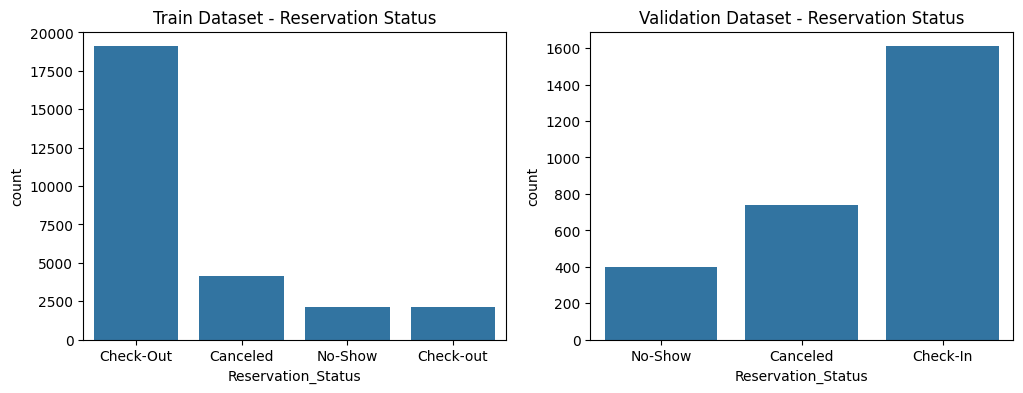

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Reservation_Status', data=train)
plt.title("Train Dataset - Reservation Status")

plt.subplot(1,2,2)
sns.countplot(x='Reservation_Status', data=validation)
plt.title("Validation Dataset - Reservation Status")

plt.show()

Hotel Type Distribution

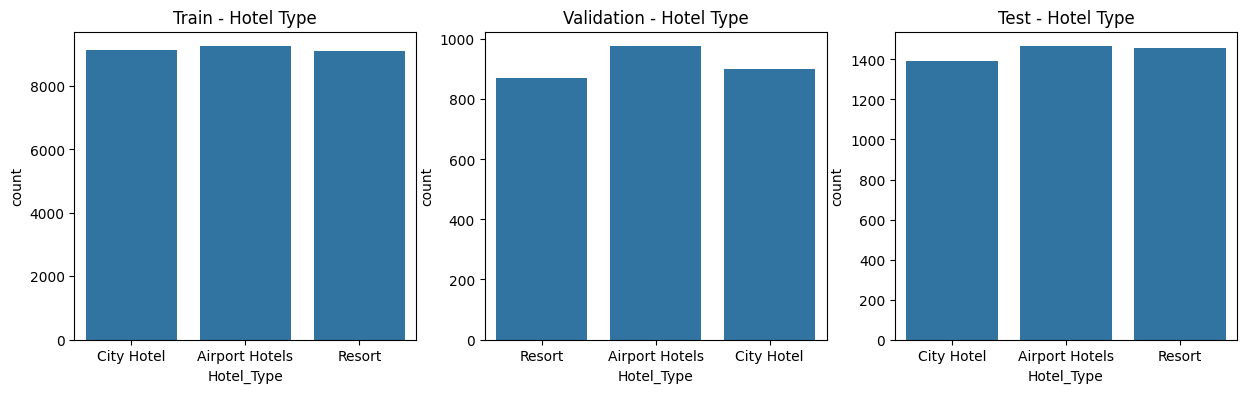

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(x='Hotel_Type', data=train)
plt.title("Train - Hotel Type")

plt.subplot(1,3,2)
sns.countplot(x='Hotel_Type', data=validation)
plt.title("Validation - Hotel Type")

plt.subplot(1,3,3)
sns.countplot(x='Hotel_Type', data=test)
plt.title("Test - Hotel Type")

plt.show()

Booking Channel Distribution

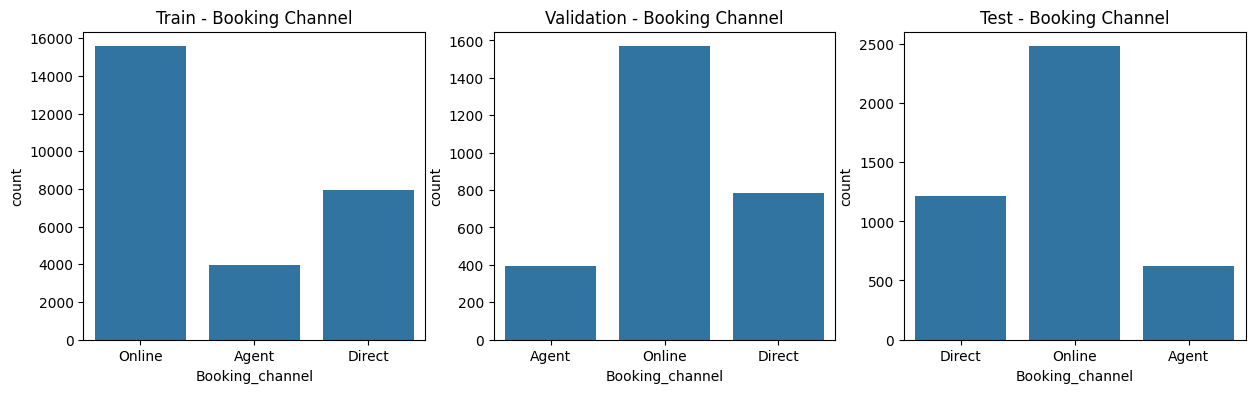

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(x='Booking_channel', data=train)
plt.title("Train - Booking Channel")

plt.subplot(1,3,2)
sns.countplot(x='Booking_channel', data=validation)
plt.title("Validation - Booking Channel")

plt.subplot(1,3,3)
sns.countplot(x='Booking_channel', data=test)
plt.title("Test - Booking Channel")

plt.show()

Room Rate Distribution

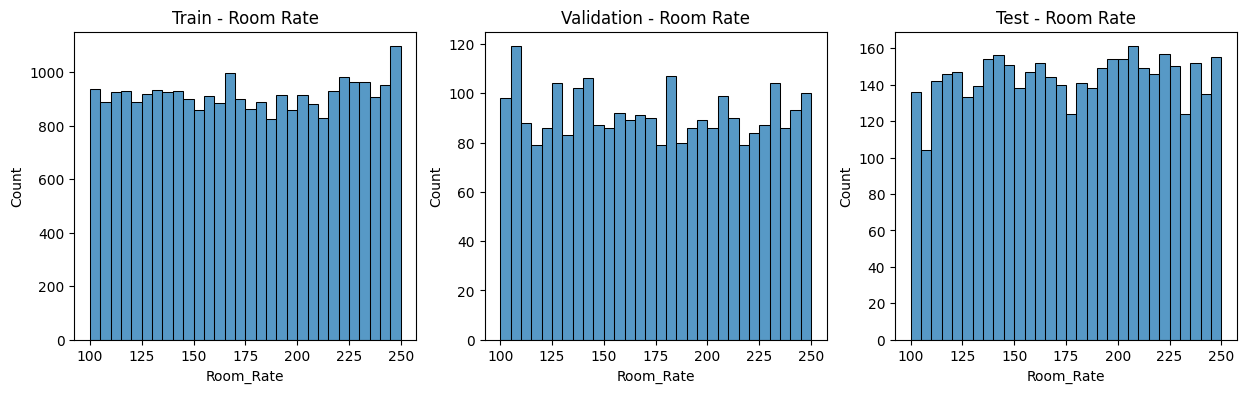

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(train['Room_Rate'], bins=30)
plt.title("Train - Room Rate")

plt.subplot(1,3,2)
sns.histplot(validation['Room_Rate'], bins=30)
plt.title("Validation - Room Rate")

plt.subplot(1,3,3)
sns.histplot(test['Room_Rate'], bins=30)
plt.title("Test - Room Rate")

plt.show()

Bivariate Analysis

Hotel Type vs Reservation Status

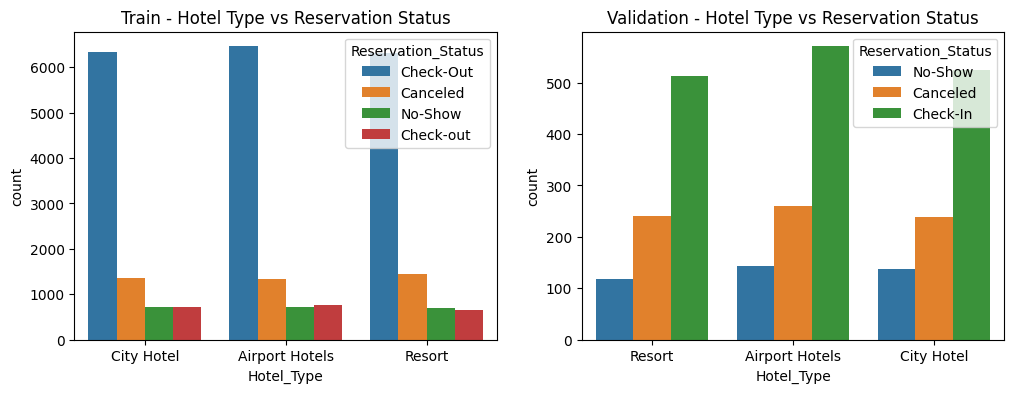

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Hotel_Type', hue='Reservation_Status', data=train)
plt.title("Train - Hotel Type vs Reservation Status")

plt.subplot(1,2,2)
sns.countplot(x='Hotel_Type', hue='Reservation_Status', data=validation)
plt.title("Validation - Hotel Type vs Reservation Status")

plt.show()

Booking Channel vs Reservation Status

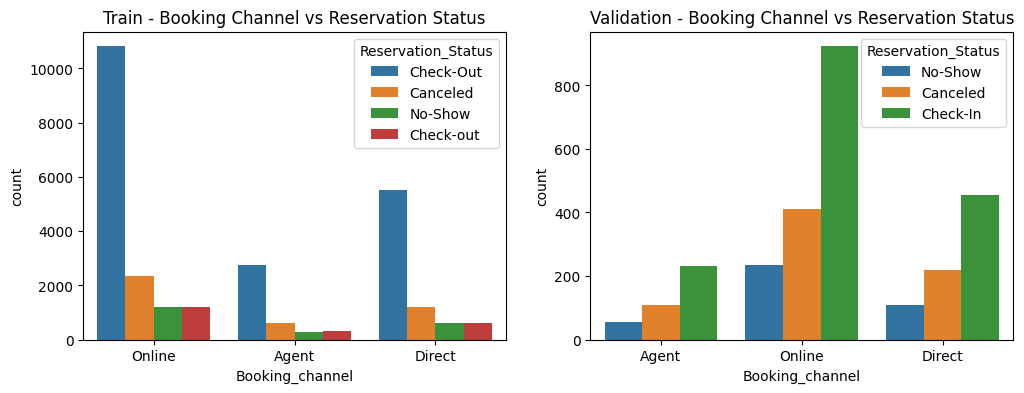

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Booking_channel', hue='Reservation_Status', data=train)
plt.title("Train - Booking Channel vs Reservation Status")

plt.subplot(1,2,2)
sns.countplot(x='Booking_channel', hue='Reservation_Status', data=validation)
plt.title("Validation - Booking Channel vs Reservation Status")

plt.show()

Room Rate vs Reservation Status

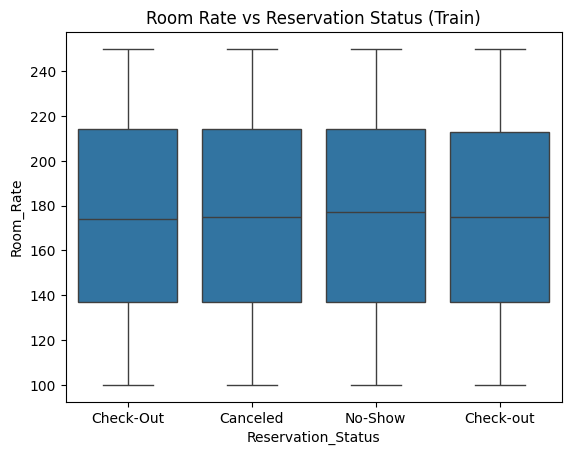

In [ ]:
sns.boxplot(x='Reservation_Status', y='Room_Rate', data=train)
plt.title("Room Rate vs Reservation Status (Train)")
plt.show()

Multivariate Analysis

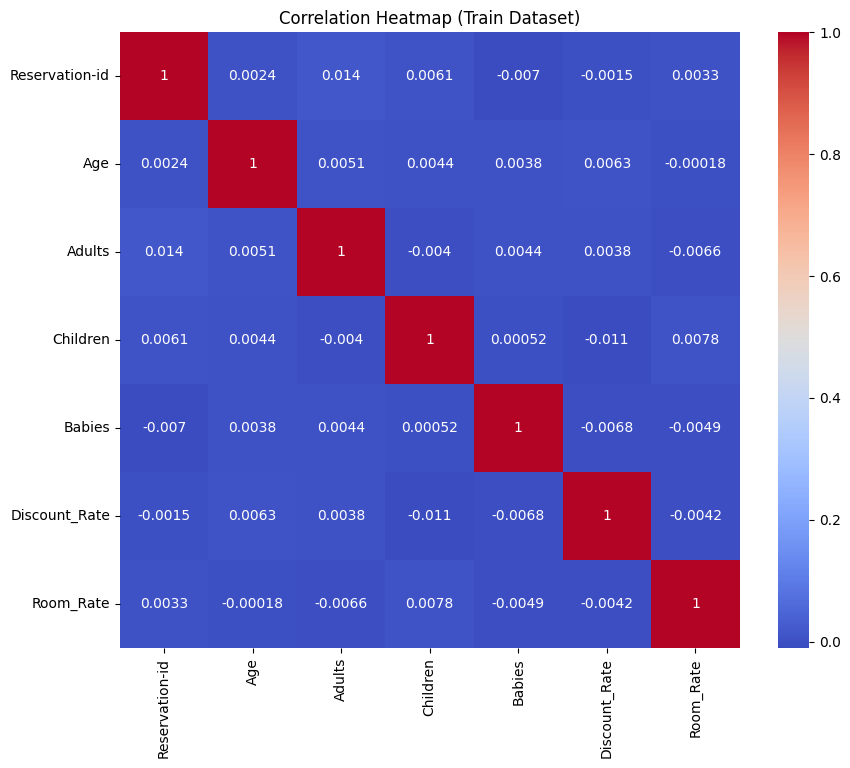

In [ ]:
plt.figure(figsize=(10,8))

numeric_cols = train.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap (Train Dataset)")
plt.show()

Hotel Type vs Booking Channel vs Reservation Status

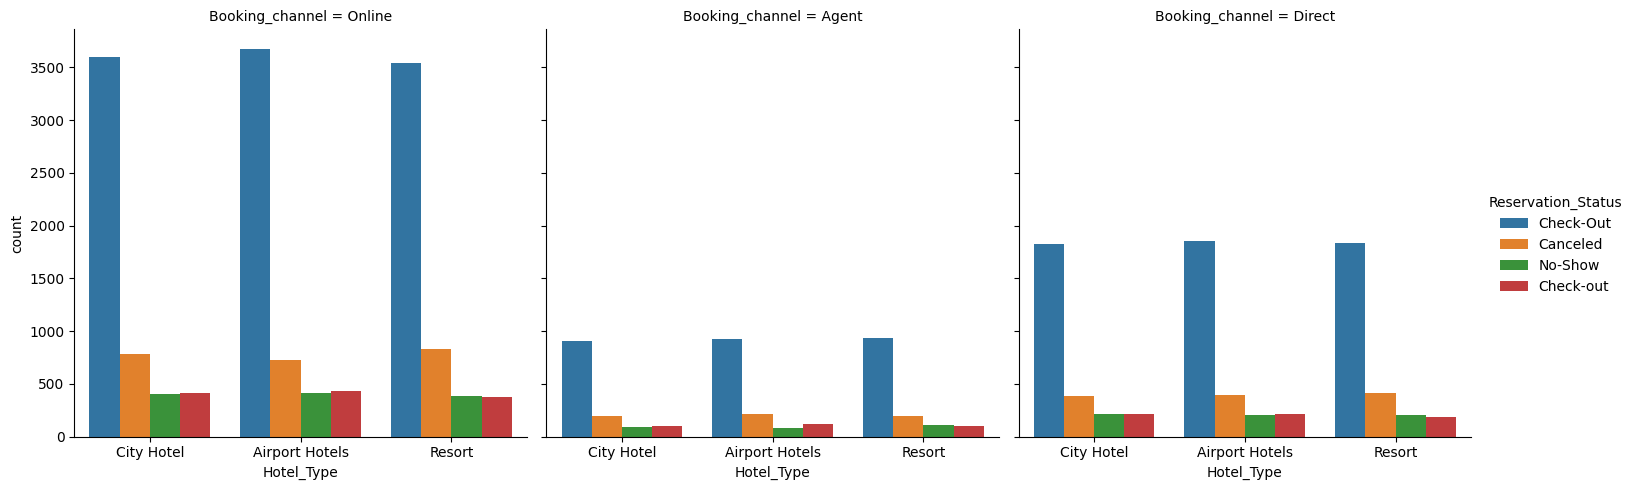

In [ ]:
sns.catplot(
    x='Hotel_Type',
    hue='Reservation_Status',
    col='Booking_channel',
    kind='count',
    data=train
)

plt.show()

An inconsistency was observed in the Reservation_Status variable, where similar categories such as “Check-Out” and “Check-out” were recorded differently. This issue appeared consistently across multiple visualisations, indicating that identical categories were treated as separate groups. Such inconsistencies can lead to fragmented counts, inaccurate summary statistics, and misleading insights. Therefore, this issue needs to be addressed during the data cleaning stage by standardising category labels.

Outliers

Outliers were detected in numerical variables across all three datasets (train, validation, and test) using the IQR method and boxplots.

In [ ]:
# Detect outliers
def detect_outliers_iqr(df, name):
    print(f"\nOutlier Summary for {name} dataset\n")

    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    outlier_summary = {}

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        outlier_summary[col] = len(outliers)

    return outlier_summary

In [ ]:
train_outliers = detect_outliers_iqr(train, "Train")
validation_outliers = detect_outliers_iqr(validation, "Validation")
test_outliers = detect_outliers_iqr(test, "Test")

train_outliers, validation_outliers, test_outliers


Outlier Summary for Train dataset


Outlier Summary for Validation dataset


Outlier Summary for Test dataset



({'Reservation-id': 0,
  'Age': 0,
  'Adults': 2286,
  'Children': 0,
  'Babies': 0,
  'Discount_Rate': 0,
  'Room_Rate': 0},
 {'Reservation-id': 0,
  'Age': 0,
  'Adults': 0,
  'Children': 0,
  'Babies': 0,
  'Discount_Rate': 0,
  'Room_Rate': 0},
 {'Reservation-id': 0,
  'Age': 0,
  'Adults': 371,
  'Children': 0,
  'Babies': 0,
  'Discount_Rate': 0,
  'Room_Rate': 0})

In [ ]:
outliers_df = pd.DataFrame({
    'Train': train_outliers,
    'Validation': validation_outliers,
    'Test': test_outliers
})

outliers_df

,Train,Validation,Test
Reservation-id,0,0,0
Age,0,0,0
Adults,2286,0,371
Children,0,0,0
Babies,0,0,0
Discount_Rate,0,0,0
Room_Rate,0,0,0


Outliers were detected primarily in the Adults variable, with a significant number observed in the training dataset (2286 cases) and some in the test dataset (371 cases). This suggests the presence of unusually high values for the number of adults per booking, which may not be realistic. Other variables such as Age, Children, and Room_Rate did not show significant outliers.

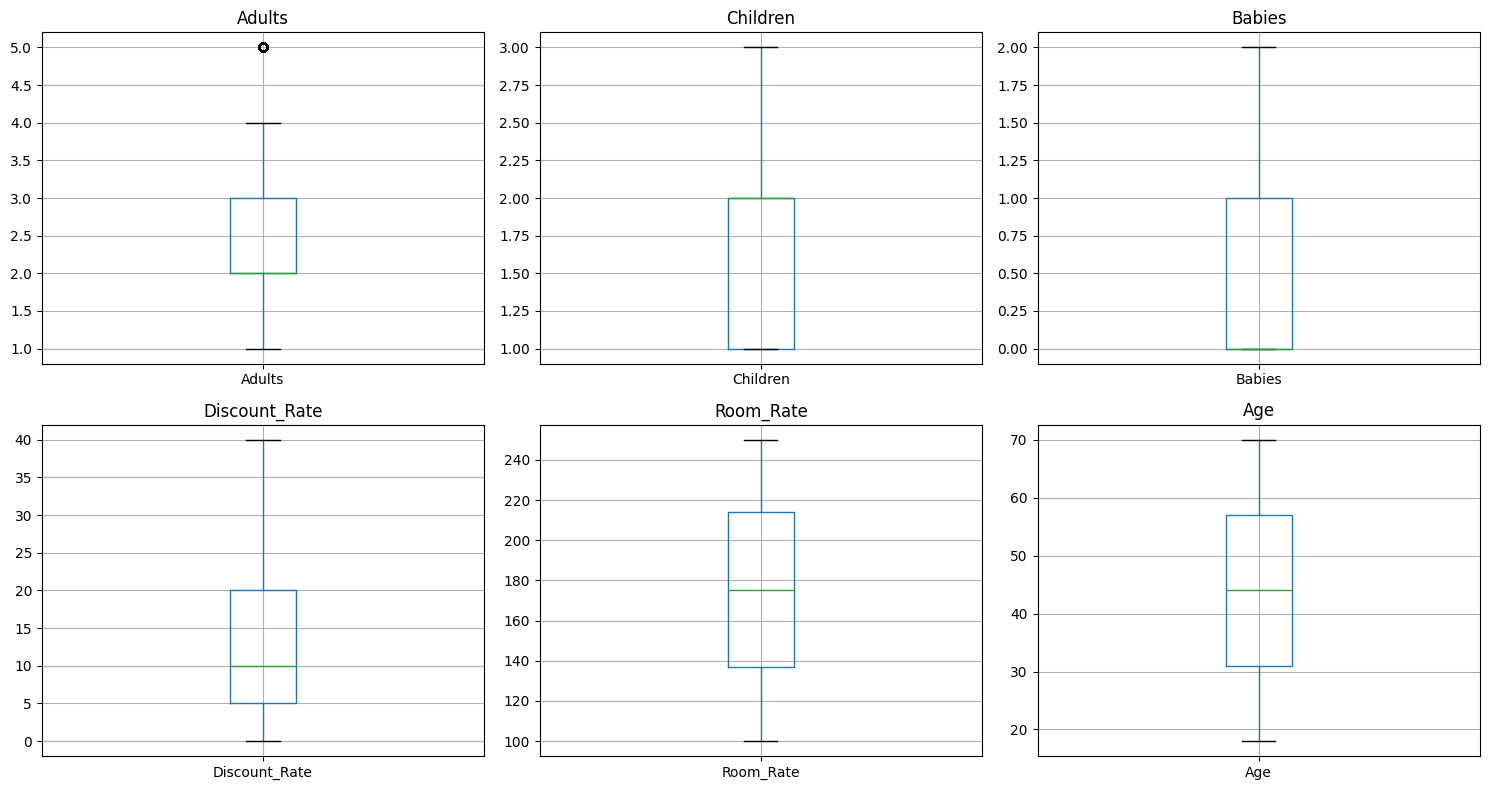

In [ ]:
cols = ['Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate', 'Age']

plt.figure(figsize=(15, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns
    train.boxplot(column=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Cap outliers using IQR method
# Calculate from TRAIN only
Q1 = train['Adults'].quantile(0.25)
Q3 = train['Adults'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Apply to all datasets
for df in [train, validation, test]:
    df['Adults'] = df['Adults'].clip(lower, upper)

Inconsistent Categorical Values

In [ ]:
train['Reservation_Status'].unique()

array(['Check-Out', 'Canceled', 'No-Show', 'Check-out'], dtype=object)

In [ ]:
train['Reservation_Status'].value_counts()

,count
Reservation_Status,
Check-Out,19092
Canceled,4134
Check-out,2148
No-Show,2125


In [ ]:
train['Reservation_Status'] = train['Reservation_Status'].str.lower().str.strip()

In [ ]:
train['Reservation_Status'] = train['Reservation_Status'].replace({
    'check out': 'checkout',
    'check-out': 'checkout'
})

In [ ]:
train['Reservation_Status'].value_counts()

,count
Reservation_Status,
checkout,21240
canceled,4134
no-show,2125


Inconsistent formatting was observed in categorical variables such as reservation_status, where similar categories appeared in different forms (e.g., “Check-Out”, “Check-out”). This resulted in duplicate categories and inaccurate counts during analysis. The issue was resolved by standardising text values through formatting and replacement, ensuring consistency across the dataset.

Exploratory Data Analysis (After Data Cleaning)

Following data cleaning, a second round of EDA was performed focusing specifically on trends and patterns related to booking cancellations. This targeted analysis helped identify key factors influencing cancellation behaviour and provided more reliable insights after addressing data quality issues.

Univariate Analysis

Cancellation Distribution

In [ ]:
train['is_canceled'] = train['Reservation_Status'].apply(
    lambda x: 1 if x.lower() in ['canceled', 'no-show'] else 0
)

Both cancellations and no-shows contribute to revenue loss, as reserved rooms remain unoccupied and may not be reallocated to other customers. Therefore, both outcomes are treated as unsuccessful bookings in the analysis.

In [ ]:
train['is_canceled'].value_counts()

,count
is_canceled,
0,21240
1,6259


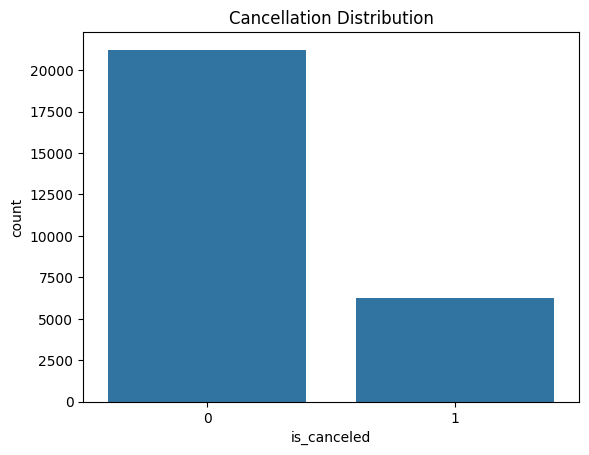

In [ ]:
sns.countplot(x='is_canceled', data=train)
plt.title("Cancellation Distribution")
plt.show()

The booking status variable is encoded as a binary outcome, where 1 denotes a cancelled booking and 0 denotes a successful booking (not cancelled). This encoding allows for straightforward analysis of cancellation patterns.

Numerical Analysis

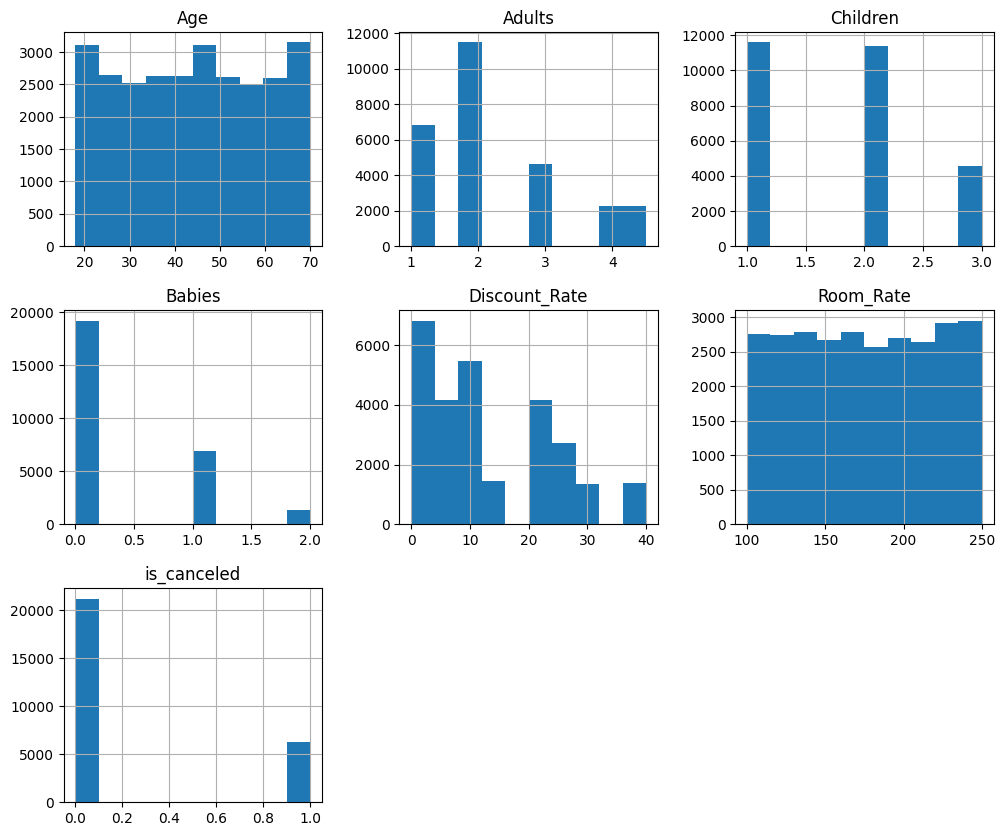

In [ ]:
# Train dataset
num_cols = train.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop(['Reservation-id'])

train[num_cols].hist(figsize=(12,10))
plt.show()

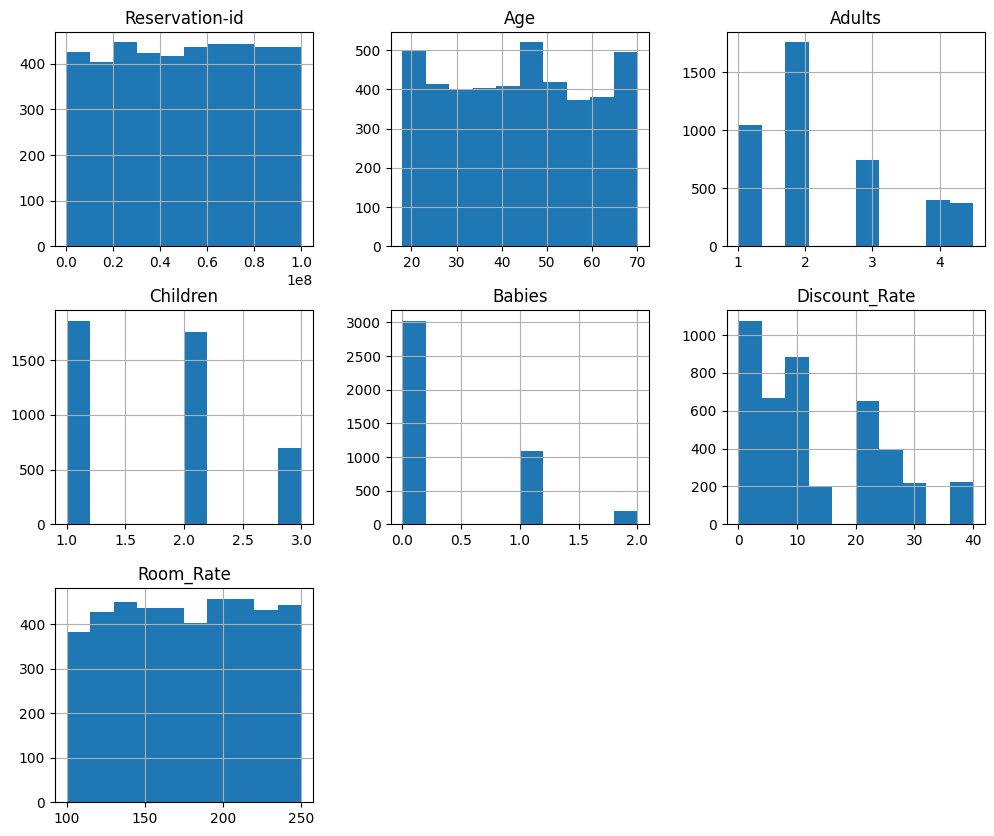

In [ ]:
# Test dataset
num_cols = test.select_dtypes(include=['int64','float64']).columns

test[num_cols].hist(figsize=(12,10))
plt.show()

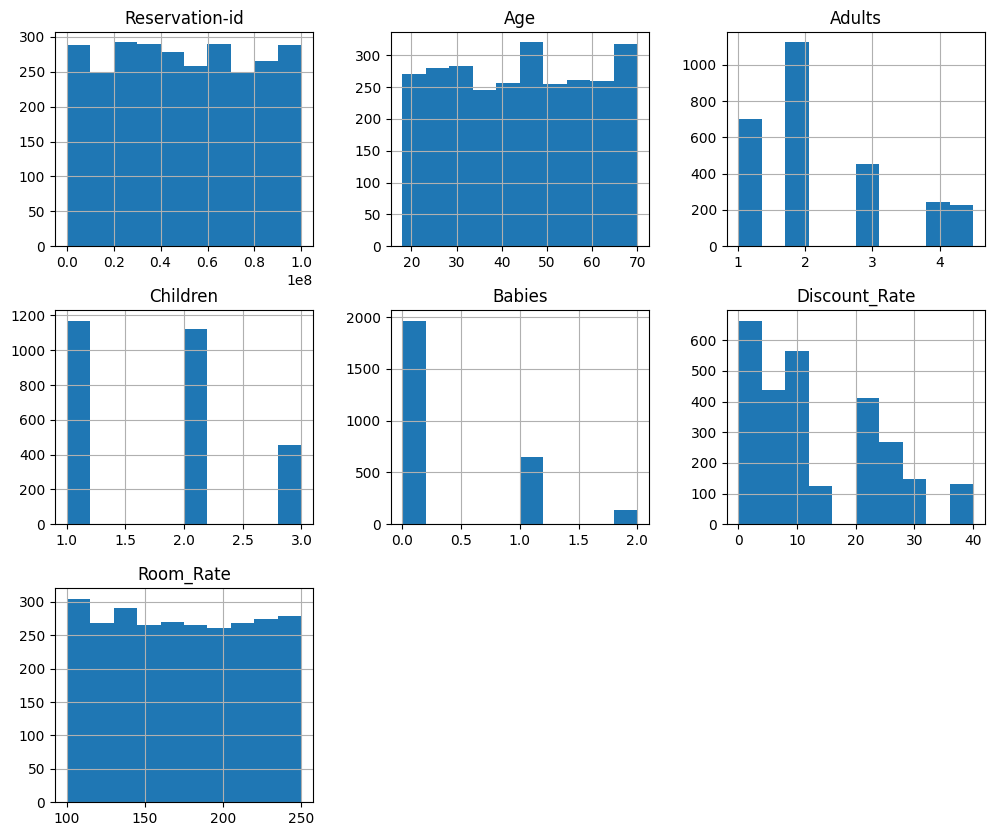

In [ ]:
# Validation dataset
num_cols = validation.select_dtypes(include=['int64','float64']).columns
validation[num_cols].hist(figsize=(12,10))
plt.show()

The distribution of numerical variables was analysed across the training, validation, and test datasets using histograms to understand their overall spread and patterns. Across all datasets, most variables show a concentration around lower values, indicating that typical bookings involve smaller group sizes and fewer additional guests. Variables related to pricing and discounts exhibit a wider range of values, suggesting variability in pricing strategies and booking conditions. The similarity in distributions across the datasets indicates consistency in data structure, which is important for reliable modelling. Overall, these patterns highlight differences in customer characteristics and booking behaviour that may influence the likelihood of cancellations.

Categorical Analysis

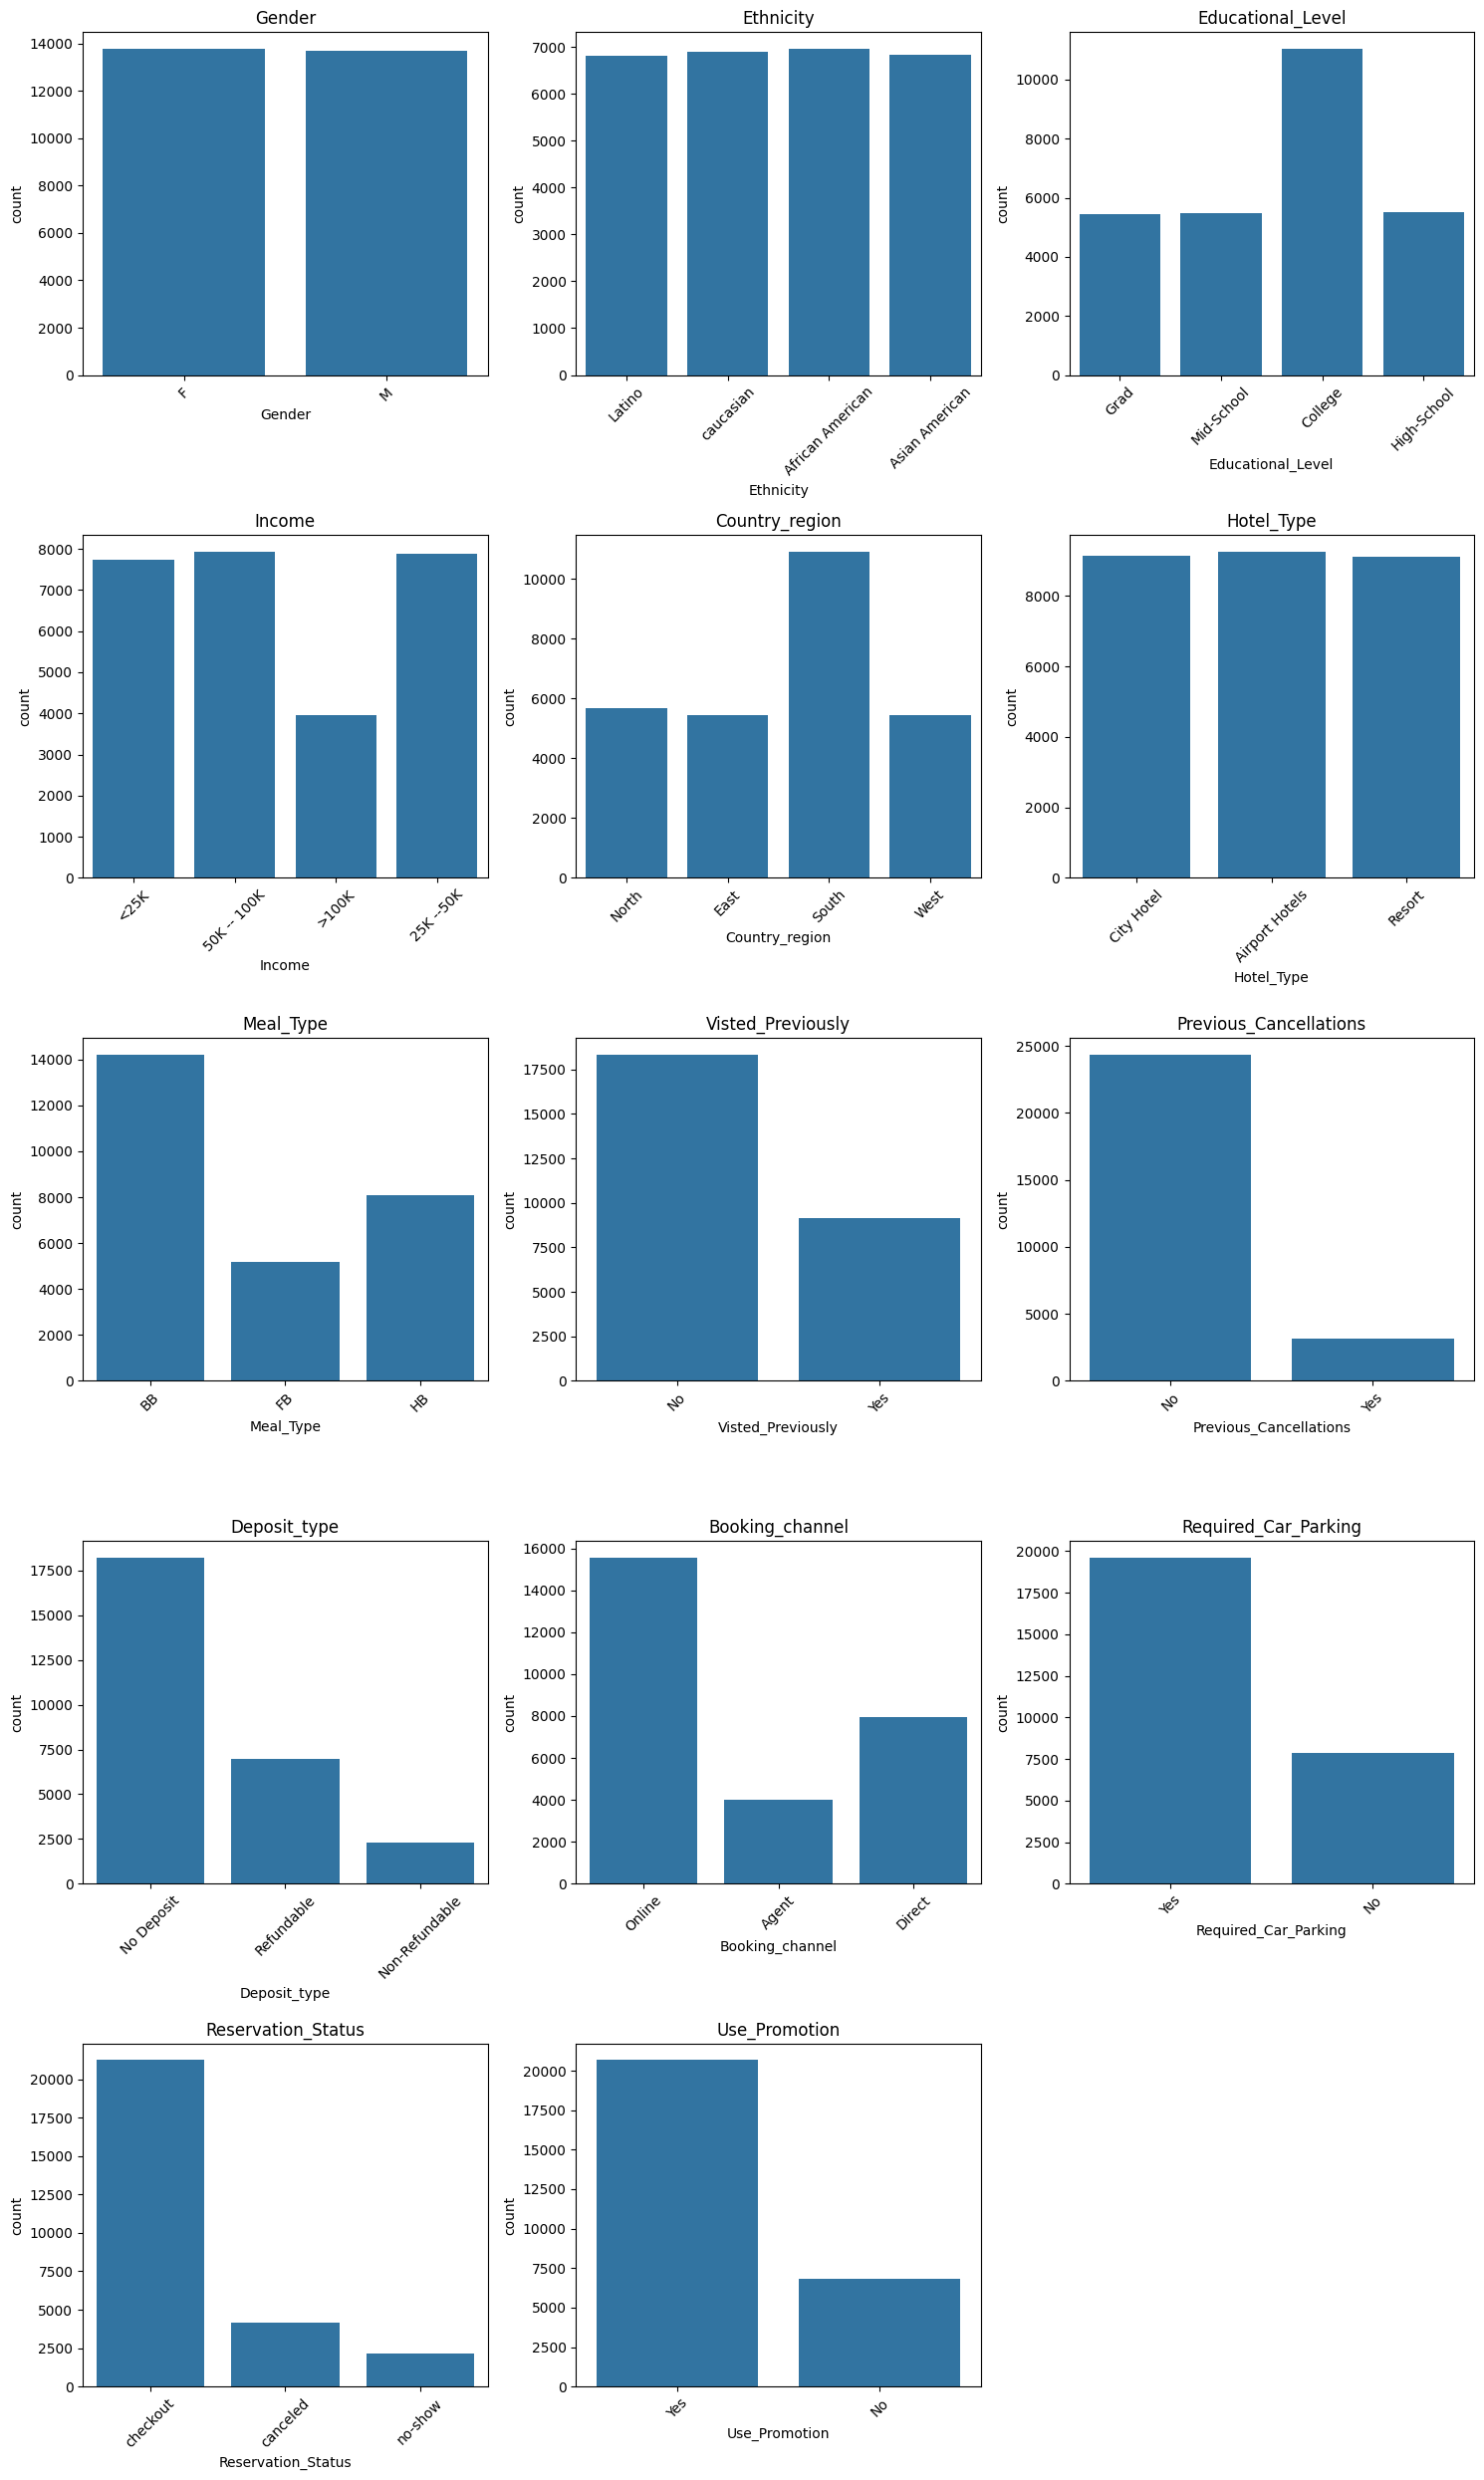

In [ ]:
cat_cols = train.select_dtypes(include='object').columns

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, data=train)
    plt.title(f"{col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The distribution of categorical variables was analysed using count plots to understand the composition of different customer and booking characteristics. The results indicate that certain categories dominate across several variables, suggesting the presence of common customer profiles and booking behaviours. Some variables exhibit relatively balanced distributions, while others show noticeable imbalances, indicating that specific groups or categories are more prevalent in the dataset. These patterns provide insight into customer segmentation and booking trends, which may play a role in influencing cancellation behaviour and are important for further analysis.

Reservation Status Distribution

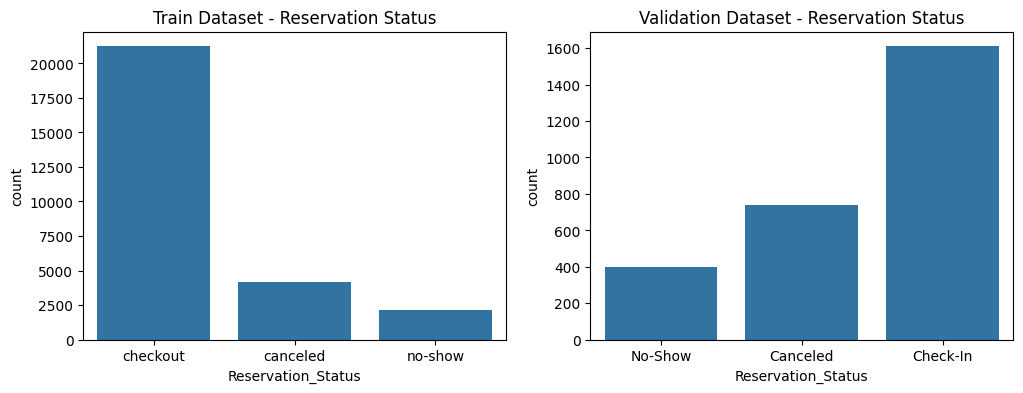

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Reservation_Status', data=train)
plt.title("Train Dataset - Reservation Status")

plt.subplot(1,2,2)
sns.countplot(x='Reservation_Status', data=validation)
plt.title("Validation Dataset - Reservation Status")

plt.show()

The distribution of reservation status was analysed across the training and validation datasets to understand booking outcomes. In the training dataset, the majority of bookings result in successful checkouts, while cancellations and no-shows occur less frequently. This indicates that although most customers complete their bookings, a notable proportion still result in revenue loss due to cancellations and no-shows.

A similar pattern is observed in the validation dataset, where successful check-ins dominate, followed by cancellations and a smaller proportion of no-shows. The consistency in distribution across both datasets suggests that the data is well-balanced and reliable for modelling purposes.

Overall, the presence of a significant number of cancellations highlights the importance of identifying key factors influencing booking behaviour in order to reduce revenue loss and improve operational efficiency.

Lead Time Distribution

In [ ]:
train.columns = train.columns.str.strip().str.lower()
validation.columns = validation.columns.str.strip().str.lower()
test.columns = test.columns.str.strip().str.lower()

train['lead_time'] = (train['expected_checkin'] - train['booking_date']).dt.days
validation['lead_time'] = (validation['expected_checkin'] - validation['booking_date']).dt.days
test['lead_time'] = (test['expected_checkin'] - test['booking_date']).dt.days

In [ ]:
train['lead_time'].describe()

,lead_time
count,27499.000000
mean,109.910906
std,78.048838
min,-4.000000
25%,45.000000
50%,101.000000
75%,166.000000
max,708.000000


In [ ]:
train = train[train['lead_time'] >= 0]
validation = validation[validation['lead_time'] >= 0]
test = test[test['lead_time'] >= 0]

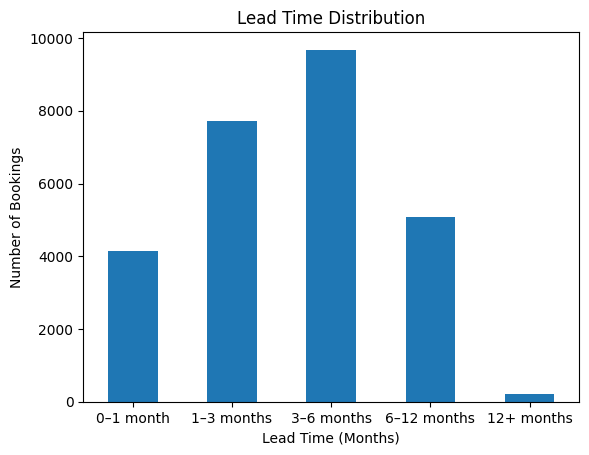

In [ ]:
# Create bins in days but label as months
bins = [0, 30, 90, 180, 365, 700]
labels = ['0–1 month', '1–3 months', '3–6 months', '6–12 months', '12+ months']

train['lead_time_group'] = pd.cut(train['lead_time'], bins=bins, labels=labels)

# Count
lead_counts = train['lead_time_group'].value_counts().sort_index()

# Plot
lead_counts.plot(kind='bar')

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Months)")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.show()

The lead time distribution shows that most bookings are made between 1 to 6 months in advance, with the highest concentration in the 3–6 months range. Fewer bookings are made very close to the check-in date (0–1 month) or far in advance (over 12 months). This suggests that customers typically plan their stays a few months ahead, which may influence cancellation behaviour, as longer lead times are often associated with higher uncertainty.

Deposit Type Distribution

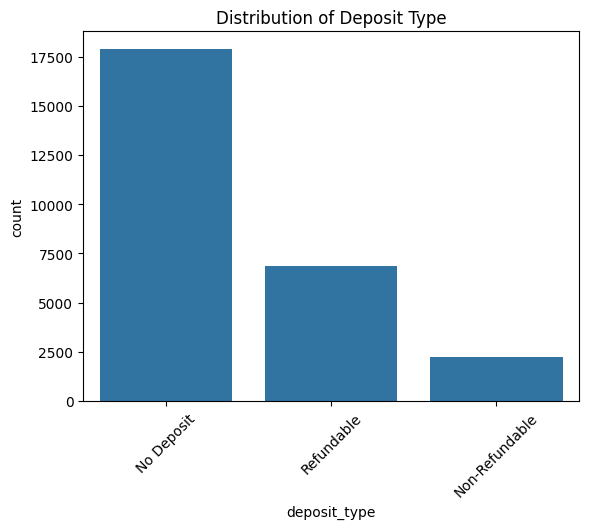

In [ ]:
sns.countplot(x='deposit_type', data=train)
plt.title('Distribution of Deposit Type')
plt.xticks(rotation=45)
plt.show()

The distribution of deposit types shows that the majority of bookings are made without any deposit, while a smaller number of bookings involve refundable deposits, and very few require non-refundable deposits. This indicates that most customers prefer flexible booking options, which may contribute to higher cancellation rates.

Bivariate Analysis

Room Rate vs Cancellation

In [ ]:
train.columns = train.columns.str.strip().str.lower()

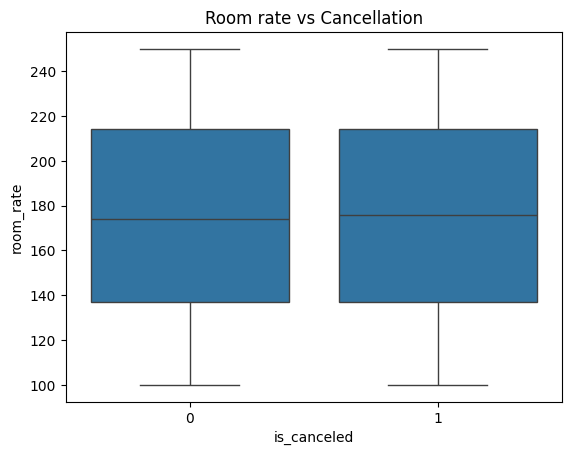

In [ ]:
sns.boxplot(x='is_canceled', y='room_rate', data=train)
plt.title("Room rate vs Cancellation")
plt.show()

The distribution of room rates is very similar for both cancelled and non-cancelled bookings.

The median and spread of room rates do not show significant differences between the two groups.

This suggests that room price alone is not a strong factor influencing booking cancellations.

Hotel Type vs Cancellation

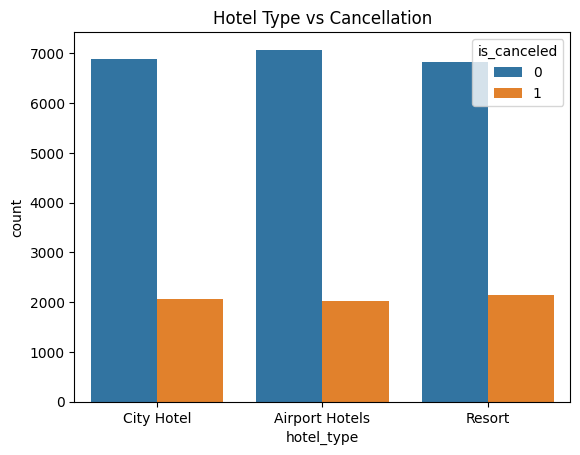

In [ ]:
sns.countplot(x='hotel_type', hue='is_canceled', data=train)
plt.title("Hotel Type vs Cancellation")
plt.show()

In [ ]:
train.groupby('hotel_type')['is_canceled'].mean()

,is_canceled
hotel_type,
Airport Hotels,0.222723
City Hotel,0.230012
Resort,0.238239


The cancellation rates across different hotel types are very similar, ranging between approximately 22% and 23.5%.

Resort hotels show a slightly higher cancellation rate, while airport hotels have the lowest.

However, the differences are minimal, indicating that hotel type does not significantly influence booking cancellations.

Customer Type vs Cancellation

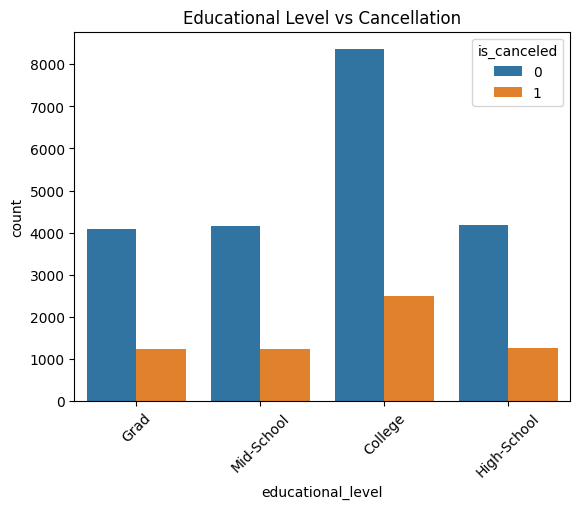

In [ ]:
sns.countplot(x='educational_level', hue='is_canceled', data=train)
plt.xticks(rotation=45)
plt.title("Educational Level vs Cancellation")
plt.show()

The chart shows the relationship between customers’ educational level and booking cancellations.

Across all education categories; Graduate, Mid-school, College, and High School, the number of non-cancelled bookings is higher than cancelled bookings.

Although the College group has the highest number of cancellations, it also has the largest number of total bookings.

Overall, the results suggest that educational level does not significantly influence cancellation behaviour, as similar patterns are observed across all groups.

Lead Time vs Reservation Status

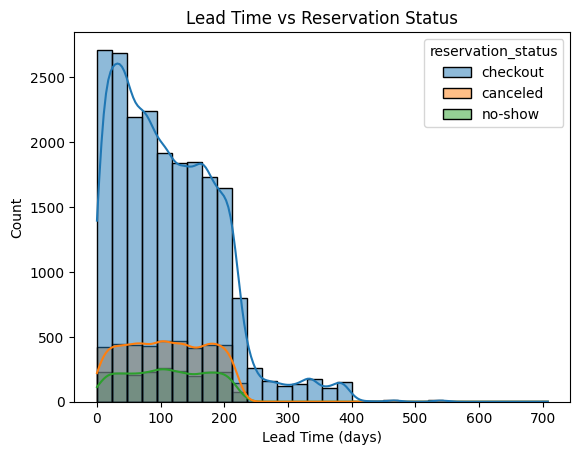

In [ ]:
sns.histplot(data=train, x='lead_time', hue='reservation_status', bins=30, kde=True)
plt.title("Lead Time vs Reservation Status")
plt.xlabel("Lead Time (days)")
plt.show()

The relationship between lead time and reservation status shows that cancellations and no-shows are more frequent at higher lead times. In contrast, successful checkouts are more concentrated at lower lead times. This suggests that bookings made further in advance are more likely to be cancelled, possibly due to greater uncertainty in customer plans.

Deposit Type vs Reservation Status

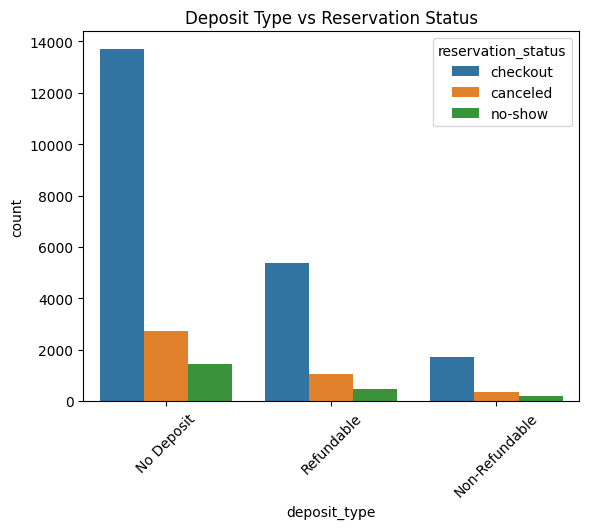

In [ ]:
sns.countplot(x='deposit_type', hue='reservation_status', data=train)
plt.title('Deposit Type vs Reservation Status')
plt.xticks(rotation=45)
plt.show()

The relationship between deposit type and reservation status shows that most bookings are made without a deposit, and these also have the highest number of cancellations and no-shows. In contrast, bookings with refundable and non-refundable deposits have relatively fewer cancellations, with non-refundable deposits showing the lowest cancellation rates. This suggests that requiring a deposit, especially non-refundable ones, increases customer commitment and reduces the likelihood of cancellations.

Deposit Type vs Cancellation

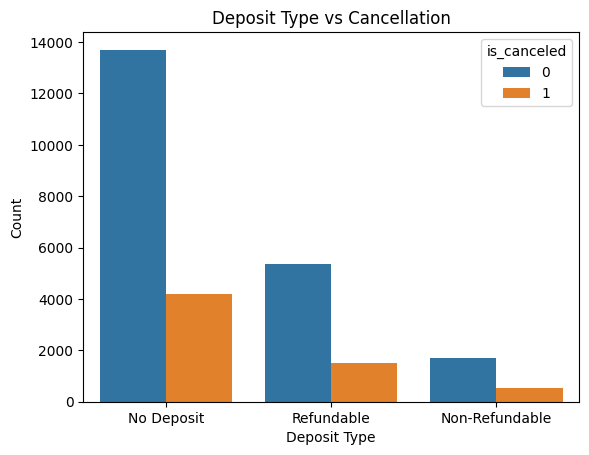

In [ ]:
sns.countplot(x='deposit_type', hue='is_canceled', data=train)
plt.title('Deposit Type vs Cancellation')
plt.xlabel('Deposit Type')
plt.ylabel('Count')
plt.show()

The chart shows that bookings with no deposit have the highest number of cancellations compared to other deposit types. In contrast, refundable and non-refundable deposits are associated with fewer cancellations, with non-refundable deposits showing the lowest cancellation counts. This suggests that requiring a deposit, especially a non-refundable one, increases customer commitment and reduces the likelihood of cancellations.

Multivariate Analysis

Hotel Type vs Booking Channel vs Reservation Status

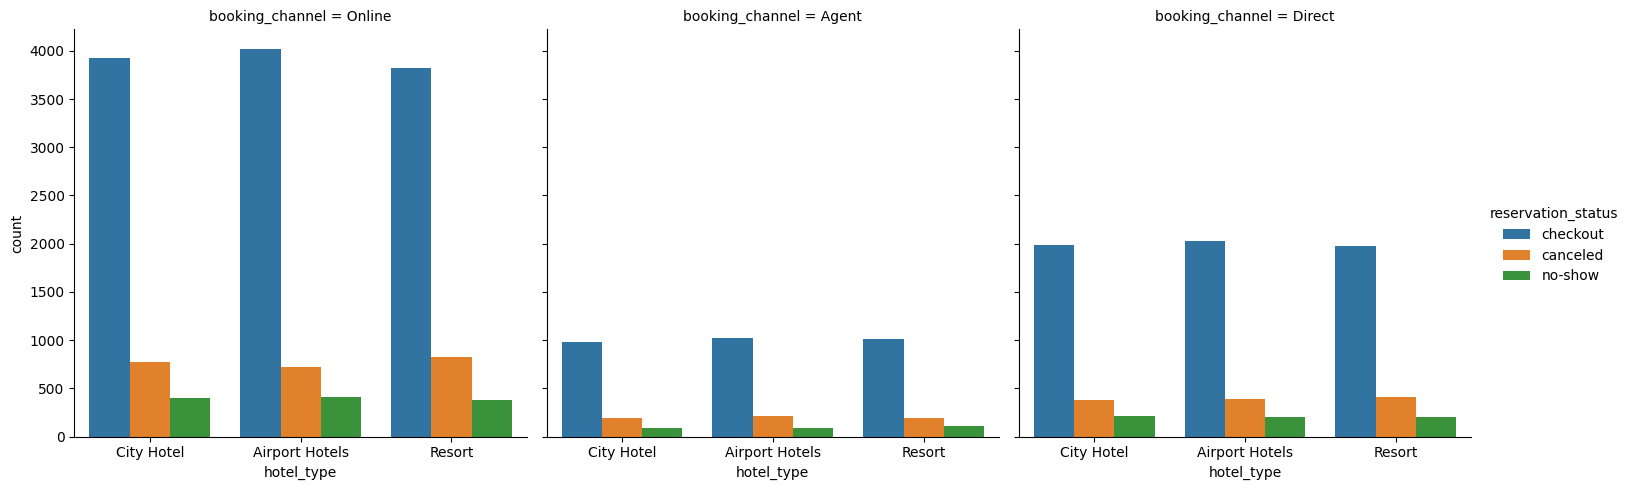

In [ ]:
sns.catplot(
    x='hotel_type',
    hue='reservation_status',
    col='booking_channel',
    kind='count',
    data=train
)

plt.show()

The relationship between hotel type, booking channel, and reservation status shows that most bookings result in successful checkouts across all hotel types and channels. Online bookings account for the highest volume of reservations, followed by direct and agent channels. While cancellations and no-shows occur across all categories, they are more noticeable in online bookings, likely due to the flexibility and ease of making changes. Overall, booking channel and hotel type appear to influence booking outcomes and may play a role in cancellation behaviour.

Correlation Matrix

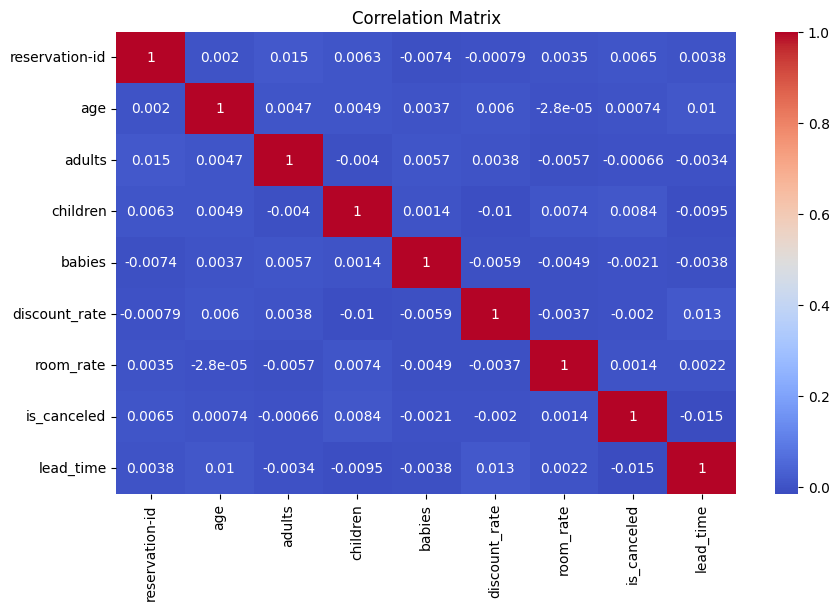

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that most variables have very weak relationships with each other, as indicated by values close to zero. This suggests low multicollinearity among features. Additionally, no single variable shows a strong correlation with cancellation, indicating that booking outcomes are likely influenced by a combination of factors rather than one dominant feature.

# Revenue Loss Analysis

Standardize Reservation Status label in the Validation dataset

In [ ]:
# Standardize reservation status in validation
validation['reservation_status'] = validation['reservation_status'].str.lower().str.strip()
validation['reservation_status'] = validation['reservation_status'].replace({'check-in': 'checkout', 'check-out': 'checkout'})

print("\nUnique statuses in train:")
print(train['reservation_status'].unique())

print("\nUnique statuses in validation:")
print(validation['reservation_status'].unique())


Unique statuses in train:
['checkout' 'canceled' 'no-show']

Unique statuses in validation:
['no-show' 'canceled' 'checkout']


Create Length of Stay

In [ ]:
for df in [train, validation, test]:
    df['Length_of_Stay'] = (df['expected_checkout'] - df['expected_checkin']).dt.days

# If any value is 0 or negative, force minimum stay to 1
for df in [train, validation, test]:
    df['Length_of_Stay'] = df['Length_of_Stay'].clip(lower=1)

print("\nLength of Stay summary - Train")
print(train['Length_of_Stay'].describe())

print("\nLength of Stay summary - Validation")
print(validation['Length_of_Stay'].describe())

print("\nLength of Stay summary - Test")
print(test['Length_of_Stay'].describe())


Length of Stay summary - Train
count    26993.000000
mean         1.828474
std          0.981751
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: Length_of_Stay, dtype: float64

Length of Stay summary - Validation
count    2733.000000
mean        1.793267
std         0.971820
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: Length_of_Stay, dtype: float64

Length of Stay summary - Test
count    4291.000000
mean        1.816127
std         0.973773
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max         4.000000
Name: Length_of_Stay, dtype: float64


Calculate Gross Revenue

In [ ]:
for df in [train, validation, test]:
    df['Gross_Revenue'] = df['room_rate'] * df['Length_of_Stay']

print("\nTrain Gross Revenue sample:")
print(train[['room_rate', 'Length_of_Stay', 'Gross_Revenue']].head())


Train Gross Revenue sample:
   room_rate  Length_of_Stay  Gross_Revenue
0        218               1            218
1        185               1            185
2        119               4            476
3        144               1            144
4        242               1            242


Calculate Net Revenue after discount

In [ ]:
for df in [train, validation, test]:
    df['Net_Revenue'] = np.where(
        df['use_promotion'] == 'Yes',
        df['Gross_Revenue'] * (1 - df['discount_rate'] / 100),
        df['Gross_Revenue']
    )

print("\nTrain Net Revenue sample:")
print(train[['Gross_Revenue', 'use_promotion', 'discount_rate', 'Net_Revenue']].head())


Train Net Revenue sample:
   Gross_Revenue use_promotion  discount_rate  Net_Revenue
0            218           Yes             10        196.2
1            185            No              0        185.0
2            476            No              0        476.0
3            144           Yes              5        136.8
4            242           Yes             10        217.8


Create Revenue Loss column

In [ ]:
# Revenue loss only for Canceled and No-Show
train['Revenue_Loss'] = np.where(
    train['reservation_status'].isin(['canceled', 'no-show']),
    train['Net_Revenue'],
    0
)

validation['Revenue_Loss'] = np.where(
    validation['reservation_status'].isin(['canceled', 'no-show']),
    validation['Net_Revenue'],
    0
)

print("\nTrain Revenue Loss sample:")
print(train[['reservation_status', 'Net_Revenue', 'Revenue_Loss']].head())

print("\nValidation Revenue Loss sample:")
print(validation[['reservation_status', 'Net_Revenue', 'Revenue_Loss']].head())


Train Revenue Loss sample:
  reservation_status  Net_Revenue  Revenue_Loss
0           checkout        196.2           0.0
1           checkout        185.0           0.0
2           checkout        476.0           0.0
3           checkout        136.8           0.0
4           checkout        217.8           0.0

Validation Revenue Loss sample:
  reservation_status  Net_Revenue  Revenue_Loss
0            no-show        326.4         326.4
1           canceled        748.0         748.0
2           canceled        204.3         204.3
3           checkout        283.5           0.0
4           checkout        196.2           0.0


Total Revenue Loss

In [ ]:
train_total_loss = train['Revenue_Loss'].sum()
validation_total_loss = validation['Revenue_Loss'].sum()

print("\nTotal Revenue Loss")
print("Train Dataset:", round(train_total_loss, 2))
print("Validation Dataset:", round(validation_total_loss, 2))


Total Revenue Loss
Train Dataset: 1737902.55
Validation Dataset: 308352.5


Revenue Loss Percentage

In [ ]:
train_loss_pct = (train['Revenue_Loss'].sum() / train['Net_Revenue'].sum()) * 100
validation_loss_pct = (validation['Revenue_Loss'].sum() / validation['Net_Revenue'].sum()) * 100

print("\nRevenue Loss Percentage")
print("Train Dataset:", round(train_loss_pct, 2), "%")
print("Validation Dataset:", round(validation_loss_pct, 2), "%")


Revenue Loss Percentage
Train Dataset: 23.01 %
Validation Dataset: 41.4 %


Revenue loss by reservation status

In [ ]:
train_status_summary = train.groupby('reservation_status').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Net_Revenue=('Net_Revenue', 'sum'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

validation_status_summary = validation.groupby('reservation_status').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Net_Revenue=('Net_Revenue', 'sum'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

print("\nTrain - Revenue Loss by Reservation Status")
print(train_status_summary)

print("\nValidation - Revenue Loss by Reservation Status")
print(validation_status_summary)


Train - Revenue Loss by Reservation Status
  reservation_status  Total_Bookings  Total_Net_Revenue  Total_Revenue_Loss  \
0           canceled            4108         1150239.60          1150239.60   
1           checkout           20777         5816000.50                0.00   
2            no-show            2108          587662.95           587662.95   

   Avg_Revenue_Loss  
0        279.999903  
1          0.000000  
2        278.777491  

Validation - Revenue Loss by Reservation Status
  reservation_status  Total_Bookings  Total_Net_Revenue  Total_Revenue_Loss  \
0           canceled             738          202715.35           202715.35   
1           checkout            1602          436459.20                0.00   
2            no-show             393          105637.15           105637.15   

   Avg_Revenue_Loss  
0        274.682046  
1          0.000000  
2        268.796819  


Revenue loss by Hotel Type

In [ ]:
train_hotel_summary = train.groupby('hotel_type').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

validation_hotel_summary = validation.groupby('hotel_type').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

print("\nTrain - Revenue Loss by Hotel Type")
print(train_hotel_summary)

print("\nValidation - Revenue Loss by Hotel Type")
print(validation_hotel_summary)


Train - Revenue Loss by Hotel Type
       hotel_type  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0          Resort            8949           592381.35         66.195256
1      City Hotel            8943           574059.90         64.190976
2  Airport Hotels            9101           571461.30         62.791045

Validation - Revenue Loss by Hotel Type
       hotel_type  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0  Airport Hotels             968           110919.55        114.586312
1      City Hotel             896           100675.50        112.361049
2          Resort             869            96757.45        111.343441


Revenue loss by Deposit Type

In [ ]:
train_deposit_summary = train.groupby('deposit_type').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

validation_deposit_summary = validation.groupby('deposit_type').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

print("\nTrain - Revenue Loss by Deposit Type")
print(train_deposit_summary)

print("\nValidation - Revenue Loss by Deposit Type")
print(validation_deposit_summary)


Train - Revenue Loss by Deposit Type
     deposit_type  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0      No Deposit           17891          1162225.50         64.961461
1      Refundable            6870           430553.20         62.671499
2  Non-Refundable            2232           145123.85         65.019646

Validation - Revenue Loss by Deposit Type
     deposit_type  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0      No Deposit            1830           197157.85        107.736530
1      Refundable             684            86363.15        126.261915
2  Non-Refundable             219            24831.50        113.385845


Revenue loss by Booking Channel

In [ ]:
train_channel_summary = train.groupby('booking_channel').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

validation_channel_summary = validation.groupby('booking_channel').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

print("\nTrain - Revenue Loss by Booking Channel")
print(train_channel_summary)

print("\nValidation - Revenue Loss by Booking Channel")
print(validation_channel_summary)


Train - Revenue Loss by Booking Channel
  booking_channel  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0          Online           15291           981969.45         64.218786
1          Direct            7793           510804.70         65.546606
2           Agent            3909           245128.40         62.708723

Validation - Revenue Loss by Booking Channel
  booking_channel  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0          Online            1560           169875.20        108.894359
1          Direct             778            90857.75        116.783740
2           Agent             395            47619.55        120.555823


Revenue loss by Promotion Usage

In [ ]:
train_promo_summary = train.groupby('use_promotion').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

validation_promo_summary = validation.groupby('use_promotion').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

print("\nTrain - Revenue Loss by Promotion Usage")
print(train_promo_summary)

print("\nValidation - Revenue Loss by Promotion Usage")
print(validation_promo_summary)


Train - Revenue Loss by Promotion Usage
  use_promotion  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0            No            6709           486386.00         72.497541
1           Yes           20284          1251516.55         61.699692

Validation - Revenue Loss by Promotion Usage
  use_promotion  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0            No             660             78793.0        119.383333
1           Yes            2073            229559.5        110.737820


Analyze only lost bookings

In [ ]:
train_lost = train[train['reservation_status'].isin(['canceled', 'no-show'])].copy()
validation_lost = validation[validation['reservation_status'].isin(['canceled', 'no-show'])].copy()

print("\nTrain Lost Bookings Shape:", train_lost.shape)
print("Validation Lost Bookings Shape:", validation_lost.shape)

print("\nAverage Loss by Hotel Type (Train - lost bookings only)")
print(train_lost.groupby('hotel_type')['Revenue_Loss'].mean().sort_values(ascending=False))

print("\nAverage Loss by Hotel Type (Validation - lost bookings only)")
print(validation_lost.groupby('hotel_type')['Revenue_Loss'].mean().sort_values(ascending=False))

print("\nAverage Loss by Deposit Type (Train - lost bookings only)")
print(train_lost.groupby('deposit_type')['Revenue_Loss'].mean().sort_values(ascending=False))

print("\nAverage Loss by Deposit Type (Validation - lost bookings only)")
print(validation_lost.groupby('deposit_type')['Revenue_Loss'].mean().sort_values(ascending=False))


Train Lost Bookings Shape: (6216, 31)
Validation Lost Bookings Shape: (1131, 29)

Average Loss by Hotel Type (Train - lost bookings only)
hotel_type
Airport Hotels    281.924667
City Hotel        279.076276
Resort            277.852416
Name: Revenue_Loss, dtype: float64

Average Loss by Hotel Type (Validation - lost bookings only)
hotel_type
Airport Hotels    277.298875
Resort            271.790590
City Hotel        268.468000
Name: Revenue_Loss, dtype: float64

Average Loss by Deposit Type (Train - lost bookings only)
deposit_type
Refundable        285.512732
Non-Refundable    278.548656
No Deposit        277.579532
Name: Revenue_Loss, dtype: float64

Average Loss by Deposit Type (Validation - lost bookings only)
deposit_type
Refundable        295.764212
No Deposit        265.711388
Non-Refundable    255.994845
Name: Revenue_Loss, dtype: float64


Visualizations to show Revenue Loss


Revenue loss analysis was conducted using both the training and validation datasets to ensure consistency in patterns. However, the explanations and interpretations are primarily based on the training dataset, as it is the main dataset used to calculate and derive revenue loss insights.


In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

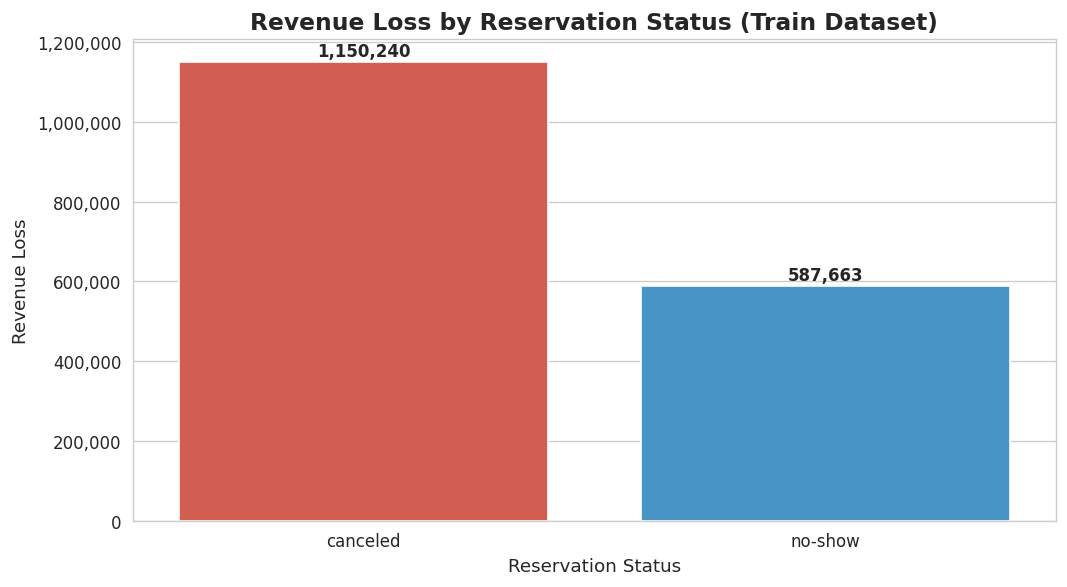

In [ ]:
import matplotlib.ticker as mtick

# Filter out checkout (no revenue loss)
train_filtered = train[train['reservation_status'] != 'checkout']

# Group data
train_status_plot = train_filtered.groupby('reservation_status', as_index=False)['Revenue_Loss'].sum()

# Order only relevant categories
status_order = ['canceled', 'no-show']
train_status_plot['reservation_status'] = pd.Categorical(
    train_status_plot['reservation_status'],
    categories=status_order,
    ordered=True
)
train_status_plot = train_status_plot.sort_values('reservation_status')

# Plot
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=train_status_plot,
    x='reservation_status',
    y='Revenue_Loss',
    hue='reservation_status',
    palette=['#e74c3c', '#3498db'],
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Reservation Status (Train Dataset)', fontweight='bold')
plt.xlabel('Reservation Status')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels
for p in ax.patches:
    height = p.get_height()
    y_pos = height + 5000 if height > 0 else 5000
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, y_pos),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Successful bookings were excluded as they do not contribute to revenue loss
Cancellations contribute the highest revenue loss (~1.15M)
No-shows contribute significantly less (~0.59M)
Cancellations and no-shows are the main contributors to overall revenue loss


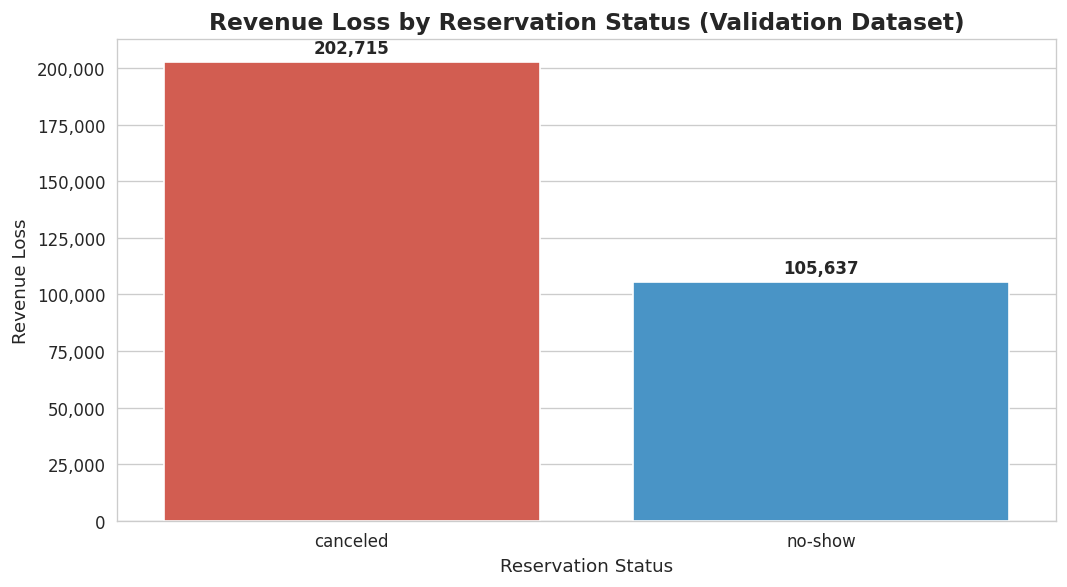

In [ ]:
# 2. Revenue Loss by Reservation Status - Validation

# Filter out checkout (no revenue loss)
validation_filtered = validation[validation['reservation_status'] != 'checkout']

# Group data
validation_status_plot = validation_filtered.groupby('reservation_status', as_index=False)['Revenue_Loss'].sum()

# Order only relevant categories
status_order = ['canceled', 'no-show']
validation_status_plot['reservation_status'] = pd.Categorical(
    validation_status_plot['reservation_status'],
    categories=status_order,
    ordered=True
)
validation_status_plot = validation_status_plot.sort_values('reservation_status')

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=validation_status_plot,
    x='reservation_status',
    y='Revenue_Loss',
    hue='reservation_status',
    palette=['#e74c3c', '#3498db'],
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Reservation Status (Validation Dataset)', fontweight='bold')
plt.xlabel('Reservation Status')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    y_pos = height + 2000 if height > 0 else 2000
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, y_pos),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

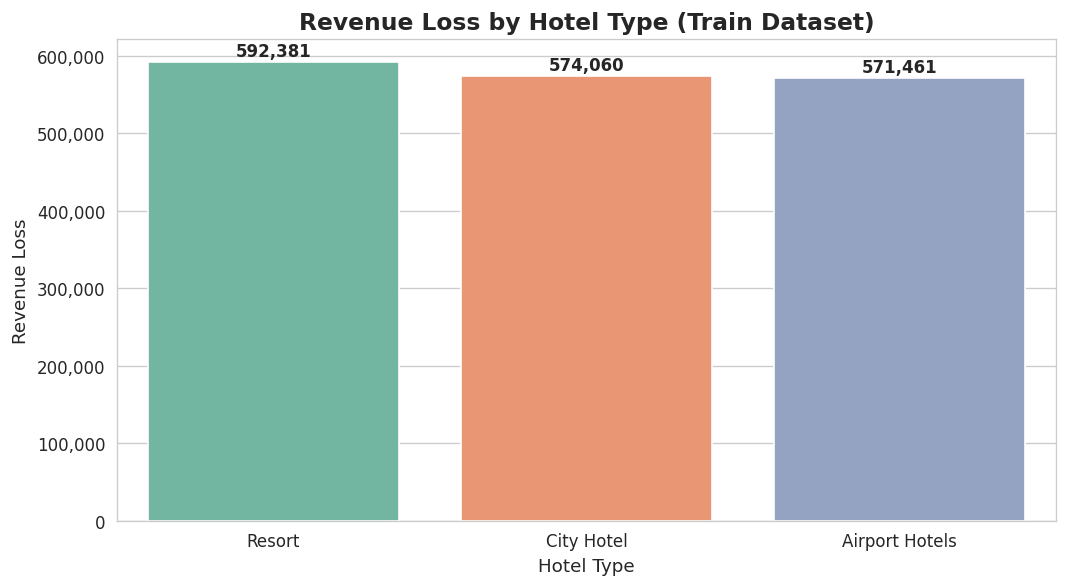

In [ ]:
# 3. Revenue Loss by Hotel Type - Train

train_hotel_plot = train.groupby('hotel_type', as_index=False)['Revenue_Loss'].sum()
train_hotel_plot = train_hotel_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=train_hotel_plot,
    x='hotel_type',
    y='Revenue_Loss',
    hue='hotel_type',
    palette='Set2',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Hotel Type (Train Dataset)', fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 3000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Revenue loss is relatively similar across all hotel types, with Resort hotels contributing the highest loss (approximately 592K), followed closely by City Hotels (around 574K) and Airport Hotels (about 571K). This indicates that revenue loss is consistently distributed across different hotel types, suggesting that cancellations and no-shows affect all segments rather than being concentrated in a specific type of hotel.


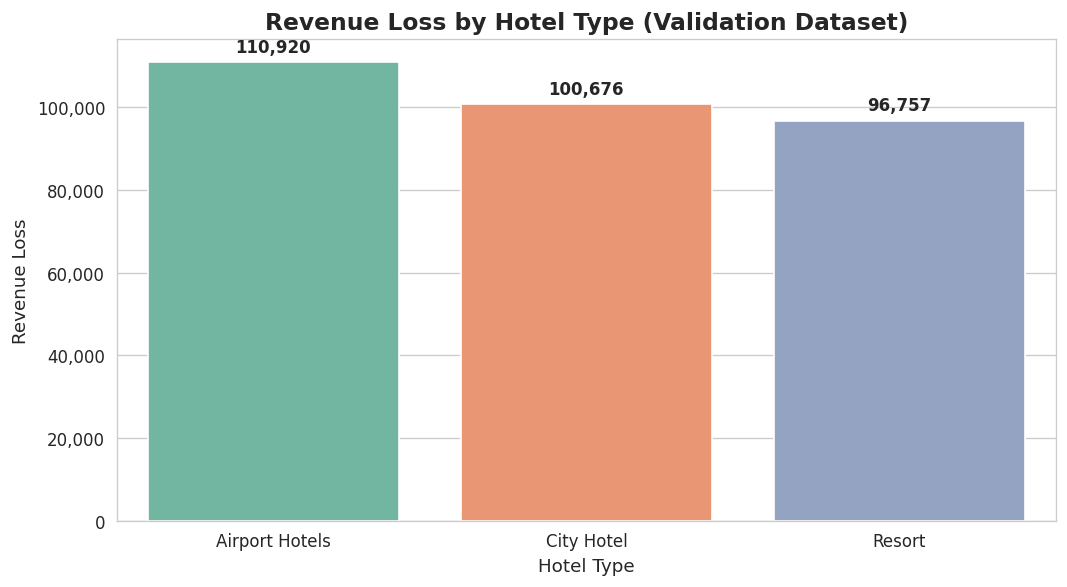

In [ ]:
# 4. Revenue Loss by Hotel Type - Validation

validation_hotel_plot = validation.groupby('hotel_type', as_index=False)['Revenue_Loss'].sum()
validation_hotel_plot = validation_hotel_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=validation_hotel_plot,
    x='hotel_type',
    y='Revenue_Loss',
    hue='hotel_type',
    palette='Set2',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Hotel Type (Validation Dataset)', fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 1500),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

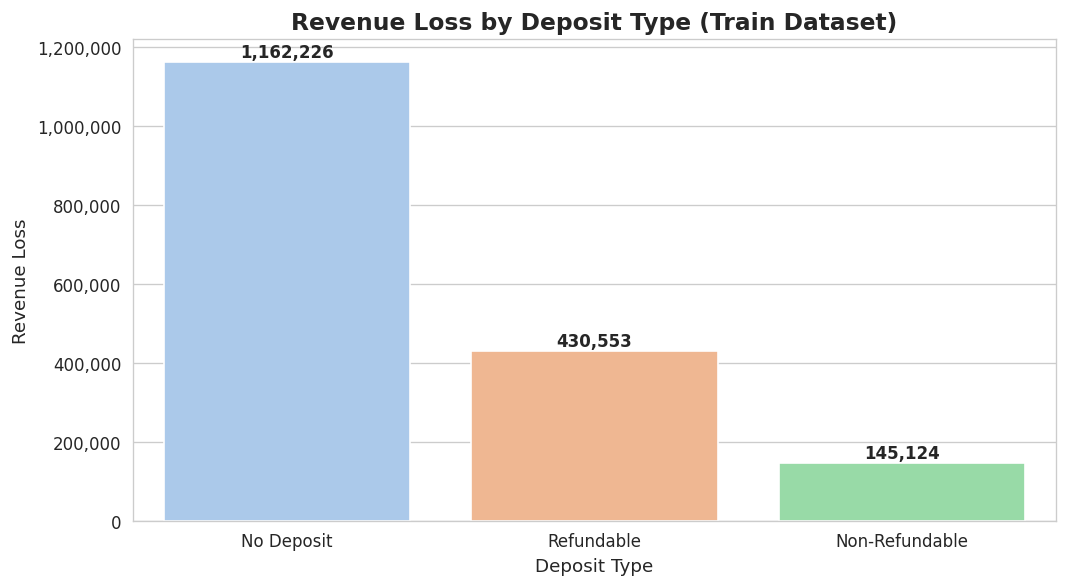

In [ ]:
# 5. Revenue Loss by Deposit Type - Train

train_deposit_plot = train.groupby('deposit_type', as_index=False)['Revenue_Loss'].sum()
train_deposit_plot = train_deposit_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=train_deposit_plot,
    x='deposit_type',
    y='Revenue_Loss',
    hue='deposit_type',
    palette='pastel',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Deposit Type (Train Dataset)', fontweight='bold')
plt.xlabel('Deposit Type')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 3000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

No-deposit bookings contribute the highest revenue loss (approximately 1.16M), while refundable deposits show a moderate level of loss (around 0.43M). In contrast, non-refundable deposits result in the lowest revenue loss (about 0.15M). This suggests that revenue loss can be reduced by limiting no-deposit bookings or introducing stricter deposit policies.


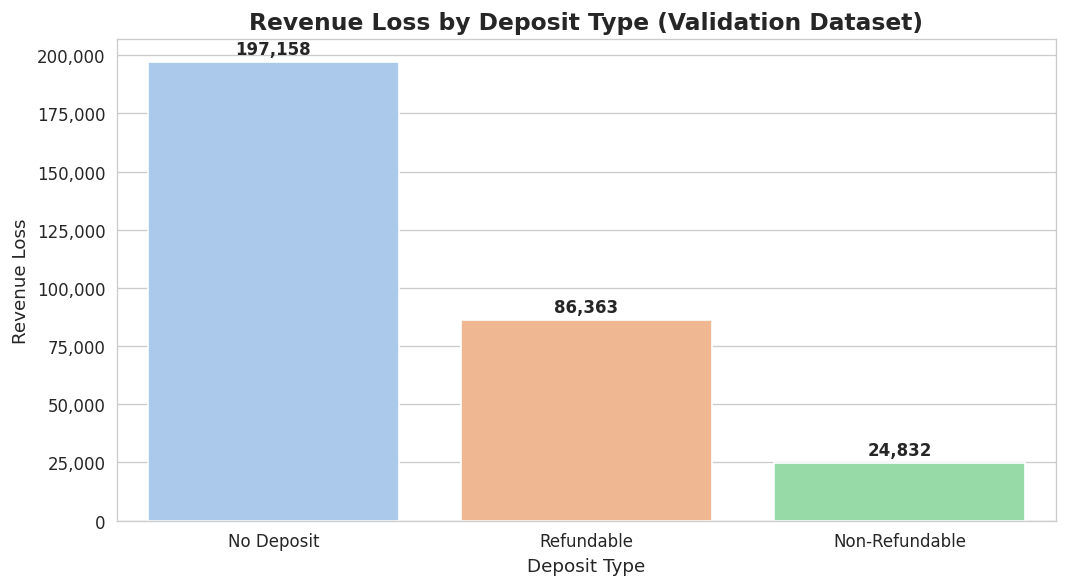

In [ ]:
# 6. Revenue Loss by Deposit Type - Validation

validation_deposit_plot = validation.groupby('deposit_type', as_index=False)['Revenue_Loss'].sum()
validation_deposit_plot = validation_deposit_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=validation_deposit_plot,
    x='deposit_type',
    y='Revenue_Loss',
    hue='deposit_type',
    palette='pastel',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Deposit Type (Validation Dataset)', fontweight='bold')
plt.xlabel('Deposit Type')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 1500),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

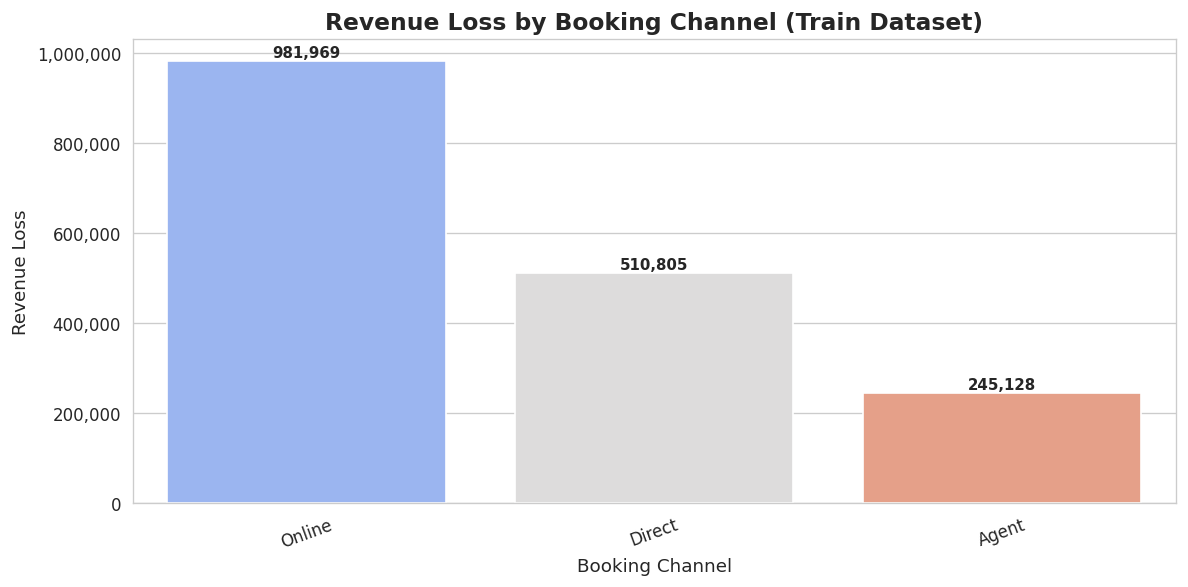

In [ ]:
# 7. Revenue Loss by Booking Channel - Train

train_channel_plot = train.groupby('booking_channel', as_index=False)['Revenue_Loss'].sum()
train_channel_plot = train_channel_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=train_channel_plot,
    x='booking_channel',
    y='Revenue_Loss',
    hue='booking_channel',
    palette='coolwarm',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Booking Channel (Train Dataset)', fontweight='bold')
plt.xlabel('Booking Channel')
plt.ylabel('Revenue Loss')
plt.xticks(rotation=20)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 3000),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Revenue loss varies significantly across booking channels, with online bookings contributing the highest loss (approximately 981K), followed by direct bookings (around 511K), while agent bookings result in the lowest revenue loss (about 245K). This suggests that online booking channels are more prone to cancellations and no-shows, making them a key area to focus on for reducing overall revenue loss.


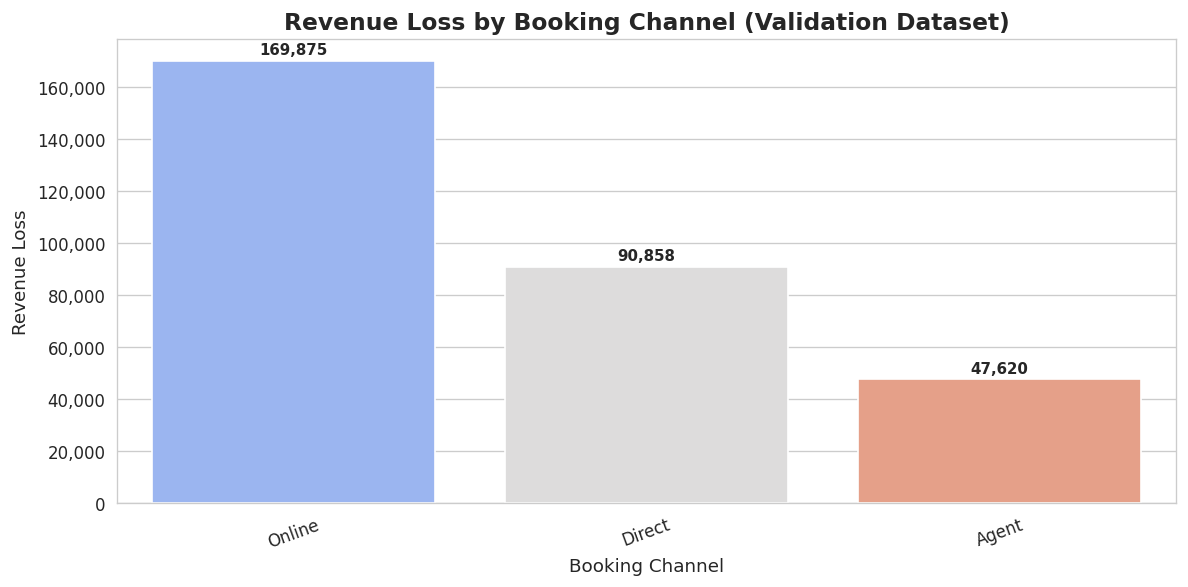

In [ ]:
# 8. Revenue Loss by Booking Channel - Validation

validation_channel_plot = validation.groupby('booking_channel', as_index=False)['Revenue_Loss'].sum()
validation_channel_plot = validation_channel_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=validation_channel_plot,
    x='booking_channel',
    y='Revenue_Loss',
    hue='booking_channel',
    palette='coolwarm',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Booking Channel (Validation Dataset)', fontweight='bold')
plt.xlabel('Booking Channel')
plt.ylabel('Revenue Loss')
plt.xticks(rotation=20)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 1500),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

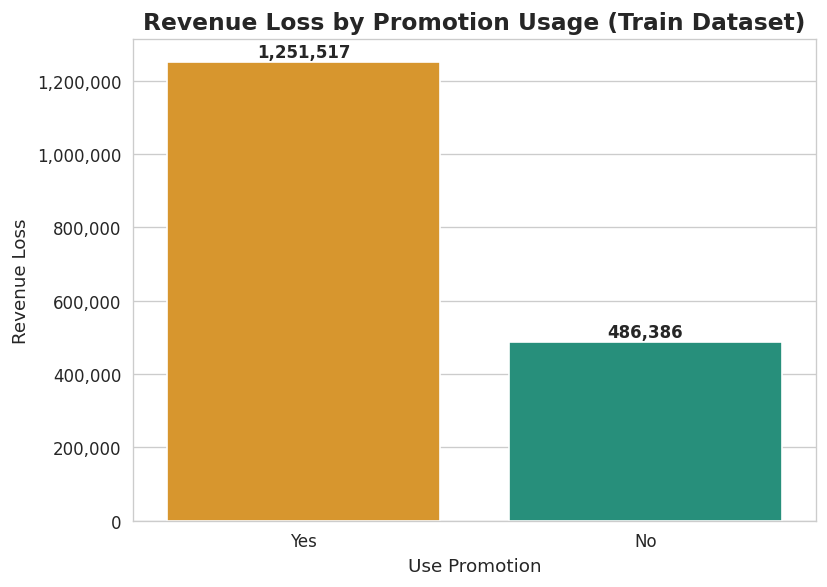

In [ ]:
# 9. Revenue Loss by Promotion Usage - Train

train_promo_plot = train.groupby('use_promotion', as_index=False)['Revenue_Loss'].sum()

promo_order = ['Yes', 'No']
train_promo_plot['use_promotion'] = pd.Categorical(
    train_promo_plot['use_promotion'],
    categories=promo_order,
    ordered=True
)
train_promo_plot = train_promo_plot.sort_values('use_promotion')

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=train_promo_plot,
    x='use_promotion',
    y='Revenue_Loss',
    hue='use_promotion',
    palette=['#f39c12', '#16a085'],
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Promotion Usage (Train Dataset)', fontweight='bold')
plt.xlabel('Use Promotion')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 3000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Revenue loss is significantly higher for bookings that used promotions, with promotional bookings contributing the highest loss (approximately 1.25M), compared to non-promotional bookings (around 0.49M). This suggests that customers using promotions may be more likely to cancel, making promotional offers a potential factor influencing revenue loss.


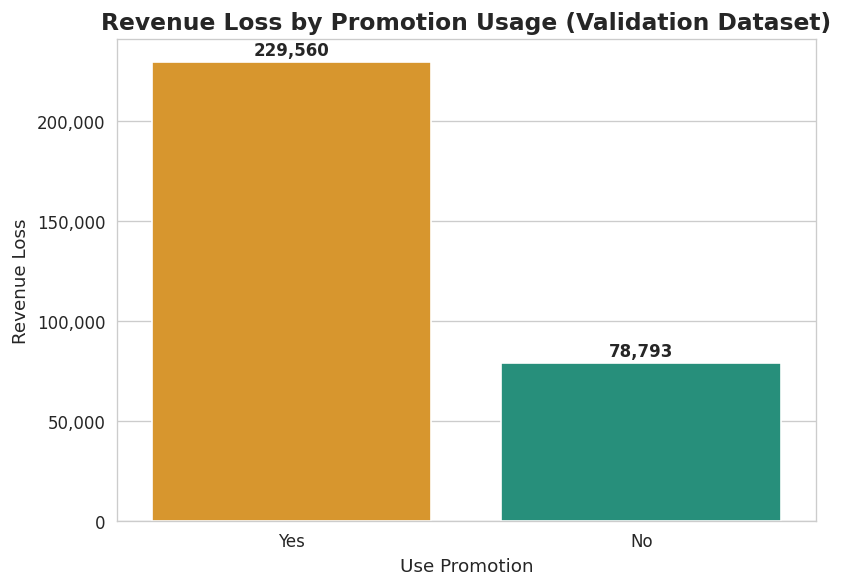

In [ ]:
# 10. Revenue Loss by Promotion Usage - Validation

validation_promo_plot = validation.groupby('use_promotion', as_index=False)['Revenue_Loss'].sum()

validation_promo_plot['use_promotion'] = pd.Categorical(
    validation_promo_plot['use_promotion'],
    categories=promo_order,
    ordered=True
)
validation_promo_plot = validation_promo_plot.sort_values('use_promotion')

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=validation_promo_plot,
    x='use_promotion',
    y='Revenue_Loss',
    hue='use_promotion',
    palette=['#f39c12', '#16a085'],
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Promotion Usage (Validation Dataset)', fontweight='bold')
plt.xlabel('Use Promotion')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 1500),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_310/2394423164.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_filtered['lead_time_group'] = pd.cut(
/tmp/ipykernel_310/2394423164.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_lead_plot = train_filtered.groupby('lead_time_group', as_index=False)['Revenue_Loss'].sum()
/tmp/ipykernel_310/2394423164.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


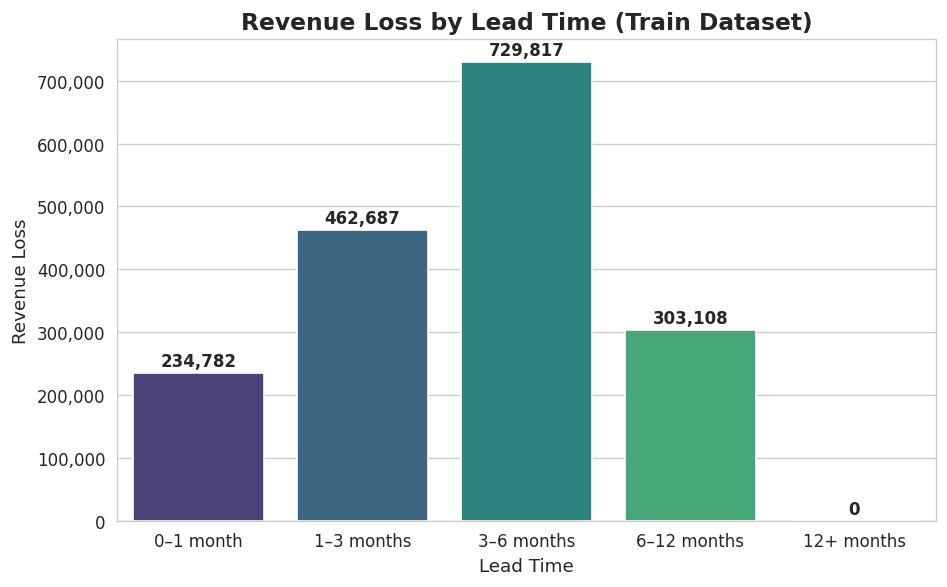

In [ ]:
# 11 Revenue Loss by Lead time - Train

# Filter out successful bookings (important)
train_filtered = train[train['reservation_status'] != 'checkout']

# Create lead time groups (months-style bins)
bins = [0, 30, 90, 180, 365, 700]
labels = ['0–1 month', '1–3 months', '3–6 months', '6–12 months', '12+ months']

train_filtered['lead_time_group'] = pd.cut(
    train_filtered['lead_time'],
    bins=bins,
    labels=labels
)

# Group revenue loss
train_lead_plot = train_filtered.groupby('lead_time_group', as_index=False)['Revenue_Loss'].sum()

# Sort properly
train_lead_plot['lead_time_group'] = pd.Categorical(
    train_lead_plot['lead_time_group'],
    categories=labels,
    ordered=True
)
train_lead_plot = train_lead_plot.sort_values('lead_time_group')

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=train_lead_plot,
    x='lead_time_group',
    y='Revenue_Loss',
    palette='viridis'
)

plt.title('Revenue Loss by Lead Time (Train Dataset)', fontweight='bold')
plt.xlabel('Lead Time')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 5000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Revenue loss increases with lead time, peaking at 3–6 months (approximately 729K), while bookings made 1–3 months in advance also show relatively high revenue loss (around 463K). In contrast, short lead times (0–1 month) have the lowest revenue loss (about 235K). After 6 months, revenue loss begins to decline, with minimal loss beyond 12 months. Overall, this indicates a positive relationship between lead time and revenue loss up to a certain point.


/tmp/ipykernel_310/708475033.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_filtered['lead_time_group'] = pd.cut(
/tmp/ipykernel_310/708475033.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  validation_lead_plot = validation_filtered.groupby('lead_time_group', as_index=False)['Revenue_Loss'].sum()
/tmp/ipykernel_310/708475033.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


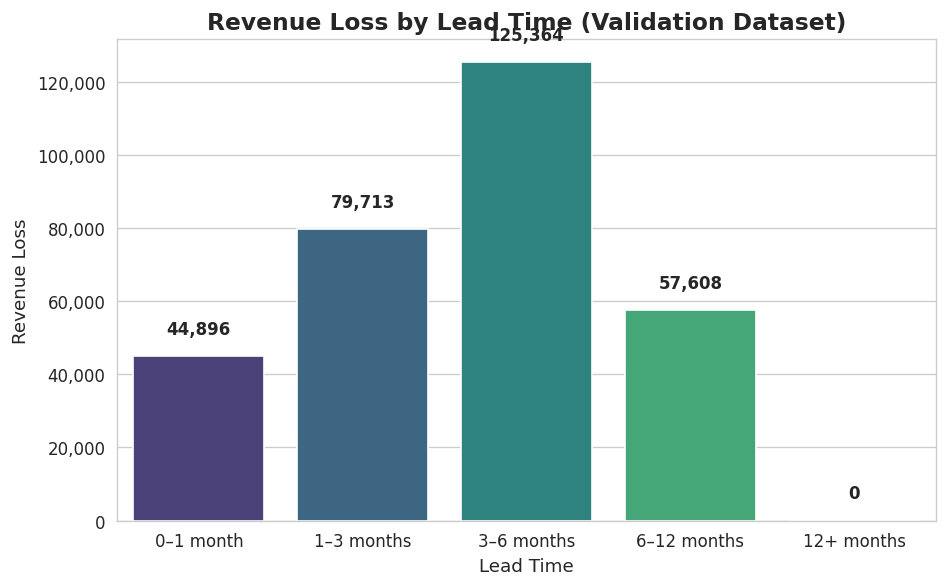

In [ ]:
# 12 Revenue Loss by Lead time - Validation

# Filter out successful bookings
validation_filtered = validation[validation['reservation_status'] != 'checkout']

# Create lead time groups
bins = [0, 30, 90, 180, 365, 700]
labels = ['0–1 month', '1–3 months', '3–6 months', '6–12 months', '12+ months']

validation_filtered['lead_time_group'] = pd.cut(
    validation_filtered['lead_time'],
    bins=bins,
    labels=labels
)

# Group revenue loss
validation_lead_plot = validation_filtered.groupby('lead_time_group', as_index=False)['Revenue_Loss'].sum()

# Sort properly
validation_lead_plot['lead_time_group'] = pd.Categorical(
    validation_lead_plot['lead_time_group'],
    categories=labels,
    ordered=True
)
validation_lead_plot = validation_lead_plot.sort_values('lead_time_group')

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=validation_lead_plot,
    x='lead_time_group',
    y='Revenue_Loss',
    palette='viridis'
)

plt.title('Revenue Loss by Lead Time (Validation Dataset)', fontweight='bold')
plt.xlabel('Lead Time')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 5000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Save the cleaned data sets

In [ ]:
train.to_csv("/content/drive/MyDrive/GCW/Data/Cleaned/train_cleaned.csv", index=False)
validation.to_csv("/content/drive/MyDrive/GCW/Data/Cleaned/validation_cleaned.csv", index=False)
test.to_csv("/content/drive/MyDrive/GCW/Data/Cleaned/test_cleaned.csv", index=False)